#Import modules

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

#File paths

In [ ]:
results_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Cell_Reports_revisions_res'

#HMDB ID / name dictionary

In [ ]:
import pickle

with open("drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/Python_scripts/hmdb_metabolite_name_dict_ML_Theo.pkl", 'rb') as f:
  hmdb_name_dict = pickle.load(f)

In [ ]:
hmdb_name_dict

{'HMDB0000870': 'Histamine',
 'HMDB0000848': 'Stearoylcarnitine',
 'HMDB0000714': 'Hippuric acid',
 'HMDB0000191': 'L-Aspartic acid',
 'HMDB0000251': 'Taurine',
 'HMDB0003229': 'Palmitoleic acid',
 'HMDB0000562': 'Creatinine',
 'HMDB0000252': 'Sphingosine',
 'HMDB0000696': 'Methionine',
 'HMDB0000641': 'Glutamine',
 'HMDB0000827': 'Stearic acid',
 'HMDB0000806': 'Myristic acid',
 'HMDB0001316': '6-Phosphogluconic acid',
 'HMDB0000289': 'Uric acid',
 'HMDB0000162': 'Proline',
 'HMDB0000939': 'S-Adenosylhomocysteine',
 'HMDB0000262': 'Thymine',
 'HMDB0000043': 'Betaine',
 'HMDB0000156': 'Malic acid',
 'HMDB0000625': 'Gluconic acid',
 'HMDB0000532': 'Acetylglycine',
 'HMDB0003045': 'Ergothioneine',
 'HMDB0000139': 'Glyceric acid',
 'HMDB0000929': 'L-Tryptophan',
 'HMDB0000826': 'Pentadecanoic acid',
 'HMDB0002000': 'Myristoleic acid',
 'HMDB0000159': 'Phenylalanine',
 'HMDB0011737': 'gamma-Glutamylglutamic acid',
 'HMDB0000086': 'Glycerophosphocholine',
 'HMDB0006344': 'Phenylacetylglutam

In [ ]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/total_metabolites_predicted.pkl', 'rb') as file:
  correct_mets = pickle.load(file)
correct_mets

{'Ensemble': ['HMDB0000870',
  'HMDB0000848',
  'HMDB0000714',
  'HMDB0000191',
  'HMDB0000251',
  'HMDB0003229',
  'HMDB0000562',
  'HMDB0000252',
  'HMDB0000696',
  'HMDB0000641',
  'HMDB0000827',
  'HMDB0000806',
  'HMDB0001316',
  'HMDB0000289',
  'HMDB0000162',
  'HMDB0000939',
  'HMDB0000262',
  'HMDB0000043',
  'HMDB0000156',
  'HMDB0000625',
  'HMDB0000532',
  'HMDB0003045',
  'HMDB0000139',
  'HMDB0000929',
  'HMDB0000826',
  'HMDB0002000',
  'HMDB0000159',
  'HMDB0011737',
  'HMDB0000086',
  'HMDB0006344',
  'HMDB0000210',
  'HMDB0000759',
  'HMDB0001348',
  'HMDB0000134',
  'HMDB0000300',
  'HMDB0000660',
  'HMDB0000071',
  'HMDB0011503',
  'HMDB0000812',
  'HMDB0001406',
  'HMDB0001173',
  'HMDB0000182',
  'HMDB0000517',
  'HMDB0000673',
  'HMDB0000695',
  'HMDB0028691'],
 'Deep_learning_unbiased_features': ['HMDB0000195',
  'HMDB0000064',
  'HMDB0000097',
  'HMDB0000177',
  'HMDB0000167',
  'HMDB0000224',
  'HMDB0000126',
  'HMDB0000254',
  'HMDB0000767',
  'HMDB0028691',


In [ ]:
nucleotides = {'HMDB0000262': 'Thymine',
               'HMDB0000300': 'Uracil',
               'HMDB0000089': 'Cytidine',
               'HMDB0000157': 'Hypoxanthine'}

In [ ]:
nucleotides_names = [j.lower() for i,j in nucleotides.items()]
nucleotides_names

['thymine', 'uracil', 'cytidine', 'hypoxanthine']

#Data

In [ ]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/transcriptomics_tpm_metabolism_related_genes_ensembl_id.csv', index_col = 0)
rna = rna.T
rna

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
DUKE-00651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2312.188455,NaN,...,5.210511,0.120607,0.075973,0.042173,1.535001,0.000000,0.0,0.038375,0.060810,NaN
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1854.414094,NaN,...,5.140856,0.000000,0.000000,0.000000,0.437822,0.000000,0.0,0.036485,0.298714,NaN
DUKE-00653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2521.493046,NaN,...,5.866129,0.000000,0.014961,0.000000,0.906848,0.064986,0.0,0.022671,0.431106,NaN
DUKE-00654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3615.962913,NaN,...,13.270873,0.022549,0.018939,0.000000,243.252497,0.000000,0.0,0.000000,0.000000,NaN
DUKE-00657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4045.896211,NaN,...,6.234940,0.000000,0.018148,0.120887,0.330000,0.026276,0.0,0.000000,0.145258,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3727.663034,NaN,...,15.775171,0.029958,0.025161,0.000000,0.305025,0.000000,0.0,0.038128,60.821936,NaN
MSKC-00484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4620.661214,NaN,...,4.930365,0.000000,0.000000,0.016523,0.120283,0.086196,0.0,0.000000,4.971588,NaN
MSKC-00485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2403.462293,NaN,...,8.791958,0.015149,0.000000,0.127130,0.154241,0.257906,0.0,0.000000,7.760189,NaN
MSKC-00486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5986.593041,NaN,...,5.769025,0.012821,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.861628,NaN


In [ ]:
met_genes = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/FBA_metabolic_atlas_models/human_gem_associated_genes.csv')
met_genes

,gene_id,Symbol
0,ENSG00000198712,MT-CO2
1,ENSG00000198804,MT-CO1
2,ENSG00000198938,MT-CO3
3,ENSG00000198899,MT-ATP6
4,ENSG00000198886,MT-ND4
...,...,...
2879,ENSG00000167751,KLK2
2880,ENSG00000129873,CDY2B
2881,ENSG00000182415,CDY2A
2882,ENSG00000172352,CDY1B


In [ ]:
met_genes_dict = dict(zip(met_genes['gene_id'], met_genes['Symbol']))
met_genes_dict

{'ENSG00000198712': 'MT-CO2',
 'ENSG00000198804': 'MT-CO1',
 'ENSG00000198938': 'MT-CO3',
 'ENSG00000198899': 'MT-ATP6',
 'ENSG00000198886': 'MT-ND4',
 'ENSG00000212907': 'MT-ND4L',
 'ENSG00000198763': 'MT-ND2',
 'ENSG00000198840': 'MT-ND3',
 'ENSG00000156508': 'EEF1A1',
 'ENSG00000198888': 'MT-ND1',
 'ENSG00000198727': 'MT-CYB',
 'ENSG00000198695': 'MT-ND6',
 'ENSG00000198786': 'MT-ND5',
 'ENSG00000167658': 'EEF2',
 'ENSG00000111640': 'GAPDH',
 'ENSG00000167996': 'FTH1',
 'ENSG00000074800': 'ENO1',
 'ENSG00000110955': 'ATP5F1B',
 'ENSG00000084207': 'GSTP1',
 'ENSG00000196262': 'PPIA',
 'ENSG00000111669': 'TPI1',
 'ENSG00000176340': 'COX8A',
 'ENSG00000005022': 'SLC25A5',
 'ENSG00000169100': 'SLC25A6',
 'ENSG00000136810': 'TXN',
 'ENSG00000168653': 'NDUFS5',
 'ENSG00000233276': 'GPX1',
 'ENSG00000067225': 'PKM',
 'ENSG00000117450': 'PRDX1',
 'ENSG00000103257': 'SLC7A5',
 'ENSG00000228253': 'MT-ATP8',
 'ENSG00000126432': 'PRDX5',
 'ENSG00000178952': 'TUFM',
 'ENSG00000173660': 'UQCRH',


In [ ]:
rna = rna.rename(columns = met_genes_dict)
rna

,MT-CO2,MT-CO1,MT-CO3,MT-ATP6,MT-ND4,MT-ND4L,MT-ND2,MT-ND3,EEF1A1,MT-ND1,...,CEMP1,ACSM2A,ACSM2B,HS3ST4,COX6A2,ENPP7,TGM6,CYP2A13,KLK2,CDY2A
DUKE-00651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2312.188455,NaN,...,5.210511,0.120607,0.075973,0.042173,1.535001,0.000000,0.0,0.038375,0.060810,NaN
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1854.414094,NaN,...,5.140856,0.000000,0.000000,0.000000,0.437822,0.000000,0.0,0.036485,0.298714,NaN
DUKE-00653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2521.493046,NaN,...,5.866129,0.000000,0.014961,0.000000,0.906848,0.064986,0.0,0.022671,0.431106,NaN
DUKE-00654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3615.962913,NaN,...,13.270873,0.022549,0.018939,0.000000,243.252497,0.000000,0.0,0.000000,0.000000,NaN
DUKE-00657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4045.896211,NaN,...,6.234940,0.000000,0.018148,0.120887,0.330000,0.026276,0.0,0.000000,0.145258,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3727.663034,NaN,...,15.775171,0.029958,0.025161,0.000000,0.305025,0.000000,0.0,0.038128,60.821936,NaN
MSKC-00484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4620.661214,NaN,...,4.930365,0.000000,0.000000,0.016523,0.120283,0.086196,0.0,0.000000,4.971588,NaN
MSKC-00485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2403.462293,NaN,...,8.791958,0.015149,0.000000,0.127130,0.154241,0.257906,0.0,0.000000,7.760189,NaN
MSKC-00486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5986.593041,NaN,...,5.769025,0.012821,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.861628,NaN


In [ ]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/metabolomics_log2.csv', index_col = 0)
metabolites = metabolites.T
metabolites

,"1,2-propanediol","1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-eicosatrienoylglycerophosphocholine (20:3),1-margaroylglycerophosphocholine (17:0),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-linoleoylglycerophosphoethanolamine,...,malonate,metronidazole,N-carboxymethylalanine,N1-Methyl-4-pyridone-3-carboxamide,N6-methyladenosine,nicotinate ribonucleoside,norfluoxetine,palmitoleoyl ethanolamide,succinimide,thyroxine
DUKE-00651,21.037723,19.394321,17.671134,14.233610,14.384728,16.818972,15.262543,14.061858,18.733537,13.836203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00652,23.959087,19.044231,14.631118,16.423374,16.305192,13.493080,13.337998,16.244013,14.342457,14.410637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00653,20.682481,19.193116,15.608743,14.400485,15.299840,14.887658,14.486196,15.090475,16.891647,14.514168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00654,19.963768,19.653941,15.383235,15.369813,14.913759,14.578475,13.337998,14.576805,17.531595,16.108259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00657,19.677653,20.145794,17.854153,14.785590,14.445883,16.213699,13.337998,14.759995,19.931038,15.195652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,20.623605,20.772511,22.201466,23.203913,NaN,NaN,23.400548,21.974739,NaN,...,20.905649,19.987368,13.949308,18.857947,18.121721,15.876410,21.917796,14.204030,16.028156,13.218192
MSKC-00484,NaN,19.709740,21.012143,21.916148,21.409801,NaN,NaN,22.066585,23.908872,NaN,...,19.997085,19.987368,18.341589,15.813626,18.832340,15.876410,21.917796,14.081109,15.167041,13.218192
MSKC-00485,NaN,19.393769,20.316594,20.322285,20.074359,NaN,NaN,19.395849,21.530004,NaN,...,20.422488,19.987368,17.367652,19.865964,16.375009,18.547371,21.917796,13.940225,16.306077,13.218192
MSKC-00486,NaN,18.795282,19.099814,21.605296,22.077745,NaN,NaN,21.328106,20.474841,NaN,...,20.117567,19.987368,17.310323,19.386511,16.781328,15.876410,21.917796,13.940225,20.522298,13.218192


In [ ]:
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
metabolites

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
DUKE-00651,19.394321,17.671134,14.233610,14.384728,14.061858,18.733537,14.160222,17.035593,18.238785,16.193003,...,19.791208,17.280007,20.914748,13.103914,15.290542,11.141052,NaN,NaN,NaN,NaN
DUKE-00652,19.044231,14.631118,16.423374,16.305192,16.244013,14.342457,14.630229,17.097542,14.162099,16.343955,...,20.714696,17.931028,20.966490,11.180255,14.081160,15.169395,NaN,NaN,NaN,NaN
DUKE-00653,19.193116,15.608743,14.400485,15.299840,15.090475,16.891647,14.793942,16.787389,15.598227,16.307270,...,20.026746,17.416825,20.626487,12.483334,13.719496,10.940461,NaN,NaN,NaN,NaN
DUKE-00654,19.653941,15.383235,15.369813,14.913759,14.576805,17.531595,13.698657,17.498170,15.382139,14.735908,...,19.417532,17.333397,20.786484,12.785167,15.008995,11.457243,NaN,NaN,NaN,NaN
DUKE-00657,20.145794,17.854153,14.785590,14.445883,14.759995,19.931038,14.140832,16.189295,16.830153,13.092027,...,20.029593,18.298603,20.829264,12.072888,12.760453,10.473938,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,20.623605,20.772511,22.201466,23.203913,23.400548,21.974739,23.832628,21.126642,15.528993,23.714071,...,23.642103,22.356899,26.906058,13.804900,20.249497,18.873510,21.795535,21.284580,19.835953,20.788527
MSKC-00484,19.709740,21.012143,21.916148,21.409801,22.066585,23.908872,22.744470,24.818447,19.777455,22.367748,...,23.335062,18.983131,28.243038,16.627670,19.755282,19.011004,22.483612,22.112696,17.565157,21.367133
MSKC-00485,19.393769,20.316594,20.322285,20.074359,19.395849,21.530004,21.115255,21.695953,17.689438,22.340078,...,24.068418,21.271504,28.150188,13.804900,21.861710,20.761065,20.709723,22.940596,19.620601,19.702365
MSKC-00486,18.795282,19.099814,21.605296,22.077745,21.328106,20.474841,22.967082,21.579612,16.366178,22.815021,...,24.338312,22.174396,28.327350,15.008651,21.947564,18.447479,20.908825,21.293467,17.466552,20.561626


In [ ]:
#Select only nucleotide metabolism - related metabolites
metabolites = metabolites[nucleotides_names]
metabolites

,thymine,uracil,cytidine,hypoxanthine
DUKE-00651,10.542187,19.381189,16.075077,17.040694
DUKE-00652,13.198137,21.125307,13.842730,17.782648
DUKE-00653,10.542187,19.577658,14.381496,17.349649
DUKE-00654,10.542187,19.277812,14.832445,17.355138
DUKE-00657,14.767712,18.096724,15.273503,17.403980
...,...,...,...,...
MSKC-00483,13.813651,24.289602,19.619190,24.516262
MSKC-00484,16.215398,25.527830,18.130673,24.888101
MSKC-00485,16.684187,24.839875,18.648483,24.770284
MSKC-00486,16.030263,24.479196,18.666639,24.815552


#Remove outliers

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

def remove_outliers_isolationforest(data, contamination=0.05):
    """Removes outliers using Isolation Forest."""

    imputer = SimpleImputer(strategy='mean')
    data_clean = imputer.fit_transform(data)

    iso = IsolationForest(contamination=contamination)
    yhat = iso.fit_predict(data_clean)
    filtered_data = data[yhat != -1]
    return filtered_data


filtered_rna = remove_outliers_isolationforest(rna)
filtered_metabolites = remove_outliers_isolationforest(metabolites)

In [ ]:
rna = filtered_rna
metabolites = filtered_metabolites

In [ ]:
rna

,MT-CO2,MT-CO1,MT-CO3,MT-ATP6,MT-ND4,MT-ND4L,MT-ND2,MT-ND3,EEF1A1,MT-ND1,...,CEMP1,ACSM2A,ACSM2B,HS3ST4,COX6A2,ENPP7,TGM6,CYP2A13,KLK2,CDY2A
DUKE-00651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2312.188455,NaN,...,5.210511,0.120607,0.075973,0.042173,1.535001,0.000000,0.0,0.038375,0.060810,NaN
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1854.414094,NaN,...,5.140856,0.000000,0.000000,0.000000,0.437822,0.000000,0.0,0.036485,0.298714,NaN
DUKE-00653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2521.493046,NaN,...,5.866129,0.000000,0.014961,0.000000,0.906848,0.064986,0.0,0.022671,0.431106,NaN
DUKE-00654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3615.962913,NaN,...,13.270873,0.022549,0.018939,0.000000,243.252497,0.000000,0.0,0.000000,0.000000,NaN
DUKE-00657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4045.896211,NaN,...,6.234940,0.000000,0.018148,0.120887,0.330000,0.026276,0.0,0.000000,0.145258,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3727.663034,NaN,...,15.775171,0.029958,0.025161,0.000000,0.305025,0.000000,0.0,0.038128,60.821936,NaN
MSKC-00484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4620.661214,NaN,...,4.930365,0.000000,0.000000,0.016523,0.120283,0.086196,0.0,0.000000,4.971588,NaN
MSKC-00485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2403.462293,NaN,...,8.791958,0.015149,0.000000,0.127130,0.154241,0.257906,0.0,0.000000,7.760189,NaN
MSKC-00486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5986.593041,NaN,...,5.769025,0.012821,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.861628,NaN


#Log2 transformation

In [ ]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,MT-CO2,MT-CO1,MT-CO3,MT-ATP6,MT-ND4,MT-ND4L,MT-ND2,MT-ND3,EEF1A1,MT-ND1,...,CEMP1,ACSM2A,ACSM2B,HS3ST4,COX6A2,ENPP7,TGM6,CYP2A13,KLK2,CDY2A
DUKE-00651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.175667,NaN,...,2.634712,0.164281,0.105642,0.059595,1.341986,0.000000,0.0,0.054328,0.085167,NaN
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.857525,NaN,...,2.618440,0.000000,0.000000,0.000000,0.523886,0.000000,0.0,0.051700,0.377084,NaN
DUKE-00653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300635,NaN,...,2.779497,0.000000,0.021424,0.000000,0.931190,0.090834,0.0,0.032342,0.517131,NaN


#Data shuffling

In [ ]:
combined_data = pd.concat([rna, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

rna = shuffled_rna
metabolites = shuffled_metabolites

#Splitting data

In [ ]:
metabolites = metabolites.dropna(axis=1, how='all')
metabolites

,thymine,uracil,cytidine,hypoxanthine
MSKC-00623,14.363779,24.989962,22.657568,25.341623
C3L-01149,NaN,21.403000,NaN,NaN
C3N-00661,NaN,20.294000,NaN,NaN
MSKC-00649,15.094191,24.997936,19.458883,25.347553
MSKC-00458,15.875192,23.733496,18.677769,24.617172
...,...,...,...,...
MSKC-00574,14.363779,23.730156,21.107702,25.166007
MSKC-00401,14.684242,23.400811,19.936610,25.649371
MSKC-00304,17.693652,24.519345,22.299605,26.776656
CORN-01908,18.027250,22.200877,15.601105,17.474685


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(rna, metabolites, test_size=0.2, random_state=0)

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer_train = SimpleImputer(strategy='mean')
y_train_imputed = imputer_train.fit_transform(y_train)

In [ ]:
imputer_test = SimpleImputer(strategy='mean')
y_test_imputed = imputer_test.fit_transform(y_test)

In [ ]:
y_train = pd.DataFrame(y_train_imputed, columns=y_train.columns, index=y_train.index)
y_test = pd.DataFrame(y_test_imputed, columns=y_test.columns, index=y_test.index)

In [ ]:
if y_train.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [ ]:
if y_test.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [ ]:
y_train_features = y_train.columns
y_train_features

Index(['thymine', 'uracil', 'cytidine', 'hypoxanthine'], dtype='object')

#Import sklearn modules

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import MultiTaskLasso
from sklearn.linear_model import MultiTaskElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#Scoring and plotting functions

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

def get_r2_mse_rmse_plot_pred(data_y_test, model_predictions, model_type):

  r2 = r2_score(data_y_test, model_predictions)
  mse = mean_squared_error(data_y_test, model_predictions)
  rmse = mse**0.5

  print(f"R-squared: {r2}")
  print(f"Mean Squared Error (MSE): {mse}")
  print(f"Root Mean Squared Error (RMSE): {rmse}")


  plt.figure(figsize=(8, 6))
  for i in range(data_y_test.shape[1]):
      plt.scatter(data_y_test.iloc[:, i], model_predictions[:, i], alpha=0.5)

  plt.plot([data_y_test.min().min(), data_y_test.max().max()], [data_y_test.min().min(), data_y_test.max().max()], 'k--', lw=2, label='Ideal')

  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title(f"Predicted vs. Actual Values for Metabolites ({model_type})")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
  plt.grid(True)
  plt.savefig(f'{results_path}/{model_type}.svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

def plot_cv_scores(model_pipeline, model_type,cv_fold):

  imputer_metabolites = SimpleImputer(strategy='mean')
  metabolites_imputed = imputer_metabolites.fit_transform(metabolites)
  metabolites_imputed = pd.DataFrame(metabolites_imputed, columns=metabolites.columns, index=metabolites.index)

  scores = cross_val_score(model_pipeline, rna, metabolites_imputed, cv=cv_fold, scoring='neg_mean_squared_error', n_jobs = -1)

  print("Cross-validation scores:", scores)
  print("Average score:", scores.mean())

  scores = pd.DataFrame(scores)
  scores = scores.rename(columns = {0: 'Cross-validation scores'})
  scores['Cross-validation fold'] = [i + 1 for i in range(len(scores))]

  sns.lineplot(data = scores, x = 'Cross-validation fold', y = 'Cross-validation scores')
  plt.ylabel('Negative MSE')
  plt.title('Negative MSE fluctuation with CV-fold')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'{results_path}/MSE vs CV ({model_type}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.model_selection import KFold

def get_r2_cross_val(model, model_name):

  cv = KFold(n_splits=10, shuffle=True, random_state=0)

  scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs = -1)

  print("Cross-validation R-squared scores:", scores)
  print("Average R-squared score:", scores.mean())

  scores_df = pd.DataFrame({'Fold': range(1, len(scores) + 1), 'R-squared': scores})


  plt.figure(figsize=(8, 6))
  sns.lineplot(x='Fold', y='R-squared', data=scores_df, marker='o')
  plt.title(f'Cross-validation R-squared scores for {model_name}')
  plt.xlabel('Fold')
  plt.ylabel('R-squared')
  plt.savefig(f'{results_path}/R2 vs CV ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  mse = mean_squared_error(y_test, y_predicted)
  print("MSE:", mse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [ ]:
from scipy.stats import spearmanr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_spearman_correlation(model_predictions, model_name):


  actual_df = pd.DataFrame(y_test)
  if not isinstance(model_predictions, pd.DataFrame):
      pred_df = pd.DataFrame(model_predictions, columns=y_test.columns, index=y_test.index)
  else:
      pred_df = model_predictions

  actual_melt = actual_df.melt(var_name='Nucleotide', value_name='Actual')
  pred_melt = pred_df.melt(var_name='Nucleotide', value_name='Predicted')

  correlation_df = pd.DataFrame({
      'Actual': actual_melt['Actual'],
      'Predicted': pred_melt['Predicted'],
      'Nucleotide': actual_melt['Nucleotide']
  })


  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  plt.figure(figsize=(8, 6))


  sns.scatterplot(x='Actual', y='Predicted', hue='Nucleotide', data=correlation_df, alpha=0.7)

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, scatter=False, line_kws={'color': 'red'})

  plt.title(f'Spearman\'s Correlation ({model_name})')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')


  plt.text(0.05, 0.95, f'Overall Correlation: {correlation:.2f}\nP-value: {p_value:.2f}',
           transform=plt.gca().transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'{results_path}/Spearmans Corr ({model_name}).svg', bbox_inches = 'tight')
  plt.show()


In [ ]:
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions, model_name):

  residuals = (y_test - model_predictions).values.ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values ({model_name})")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig(f'{results_path}/Residuals vs Pred Values ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
def plot_r2_per_metabolite(model, model_name, X_test, y_test):
    """Plots the R2 score per metabolite for a given model in descending order."""

    y_pred = model.predict(X_test)

    r2_scores = []
    for i in range(y_test.shape[1]):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        r2_scores.append(r2)

    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})


    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)


    plt.figure(figsize=(10, 6))
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])
    plt.xticks(range(len(r2_df)), r2_df['Metabolite'], rotation=45, ha='right')
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()
    plt.savefig(f'{results_path}/R2 per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [ ]:
def get_r2_per_metabolite(model, model_name, X_test, y_test):
    """Get the R2 score per metabolite for a given model in descending order."""

    y_pred = model.predict(X_test)

    r2_scores = []
    for i in range(y_test.shape[1]):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        r2_scores.append(r2)


    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})


    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    return r2_df

In [ ]:
from scipy.stats import spearmanr

def plot_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""

    y_pred = model.predict(X_test)

    spearman_coeffs = []
    for i in range(y_test.shape[1]):
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])
        spearman_coeffs.append(coeff)


    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})


    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)


    plt.figure(figsize=(10, 6))
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])
    plt.xticks(range(len(spearman_df)), spearman_df['Metabolite'], rotation=45, ha='right')
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()
    plt.savefig(f'{results_path}/Spearman per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [ ]:
def get_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Get the Spearman's correlation coefficient per metabolite for a given model."""

    y_pred = model.predict(X_test)

    spearman_coeffs = []
    for i in range(y_test.shape[1]):
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])
        spearman_coeffs.append(coeff)


    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})


    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    return spearman_df

#Multi-task Elastic-Net

In [ ]:
pipeline_elasticnet = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiTaskElasticNet(random_state = 0))
])

In [ ]:
param_grid_elasticnet = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0.1, 0.5, 0.9]
}

In [ ]:
grid_search_elasticnet = GridSearchCV(
                                      pipeline_elasticnet,
                                      param_grid_elasticnet,
                                      cv=10,
                                      scoring='neg_mean_squared_error',
                                      n_jobs = -1
                                      )
grid_search_elasticnet.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiTaskElasticNet(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__l1_ratio': [0.1, 0.5, 0.9]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best hyperparameters for ElasticNet:", grid_search_elasticnet.best_params_)
print("Best score for ElasticNet:", grid_search_elasticnet.best_score_)

Best hyperparameters for ElasticNet: {'model__alpha': 0.1, 'model__l1_ratio': 0.9}
Best score for ElasticNet: -2.1904647312088086


In [ ]:
best_elasticnet_model = grid_search_elasticnet.best_estimator_

In [ ]:
elasticnet_predictions = best_elasticnet_model.predict(X_test)

Cross-validation scores: [-2.67942555 -1.56601772 -2.74183588 -1.6707061  -2.23105138 -2.10289654
 -2.34597398 -2.4516027  -2.17272931 -1.63725539]
Average score: -2.1599494556251733


/tmp/ipykernel_4657/2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


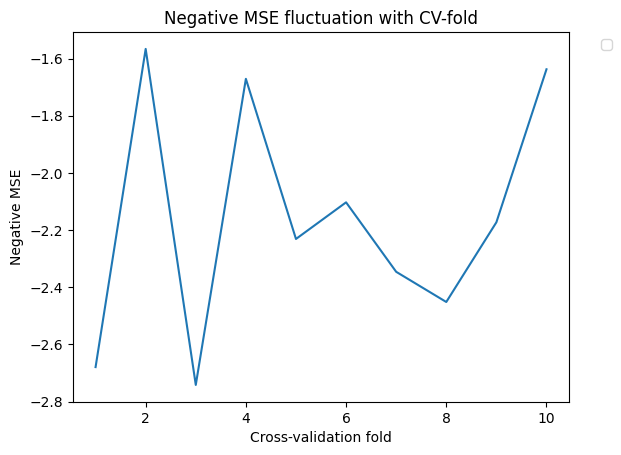

In [ ]:
plot_cv_scores(model_pipeline = best_elasticnet_model, model_type = 'Multi-task Elastic Net (All metabolites)', cv_fold = 10)

R-squared: 0.5655595718424875
Mean Squared Error (MSE): 1.997415437184931
Root Mean Squared Error (RMSE): 1.4132994860201893


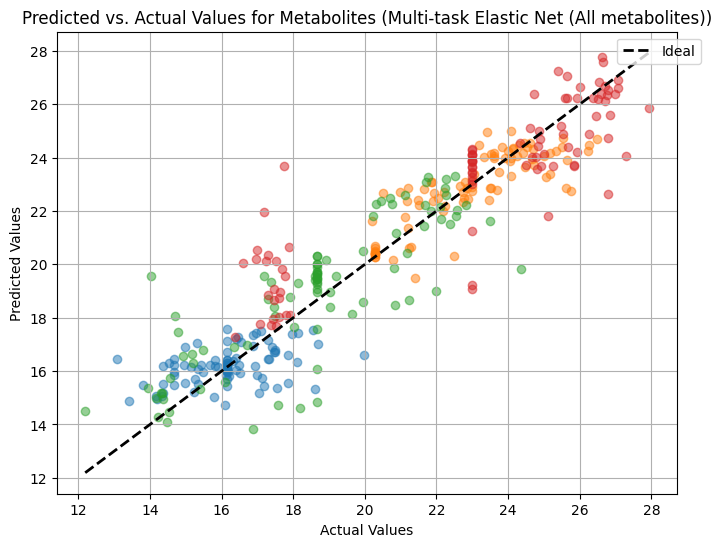

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = elasticnet_predictions, model_type = 'Multi-task Elastic Net (All metabolites)')

Cross-validation R-squared scores: [0.4618233  0.54775944 0.58973894 0.53258377 0.6251438  0.35814144
 0.57233032 0.4908402  0.58755242 0.36468274]
Average R-squared score: 0.5130596377062835


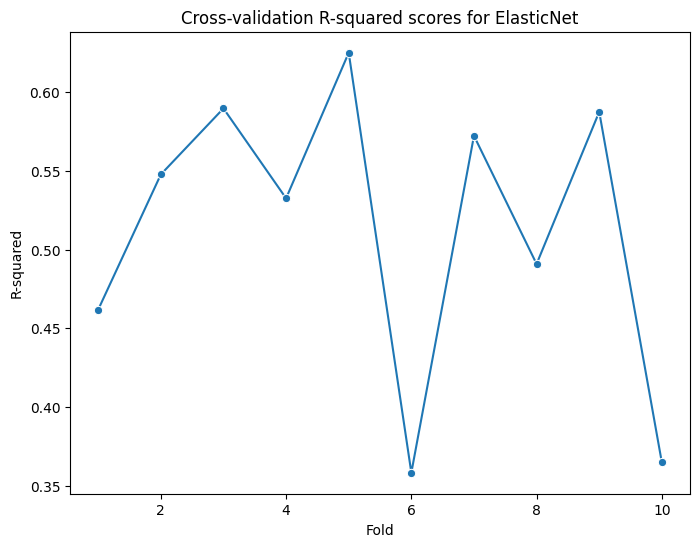

In [ ]:
get_r2_cross_val(model = best_elasticnet_model, model_name = 'ElasticNet')

In [ ]:
get_metrics(y_predicted = elasticnet_predictions)

MSE: 1.997415437184931
MAE: 1.0363998438140603
MedAE: 0.784436545407309
Mean absolute percentage error: 5.395326964918546


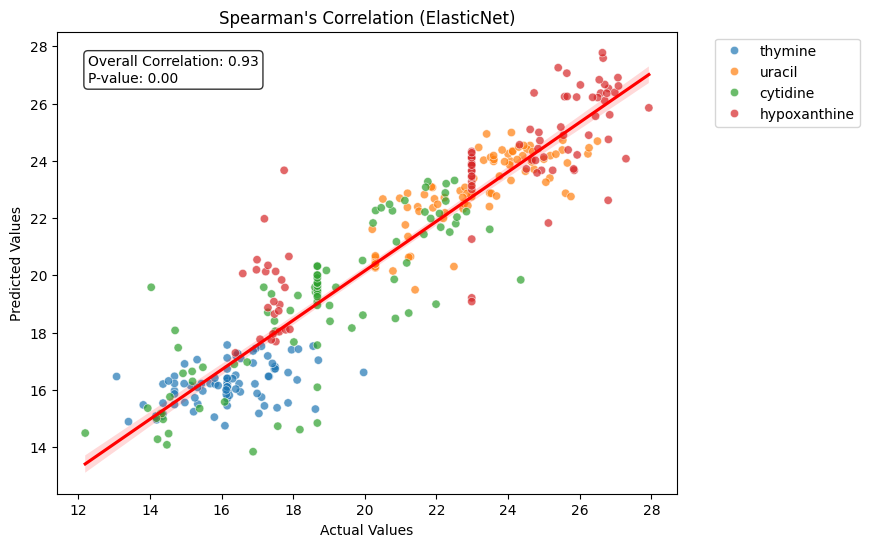

In [ ]:
get_spearman_correlation(model_predictions = elasticnet_predictions, model_name = 'ElasticNet')

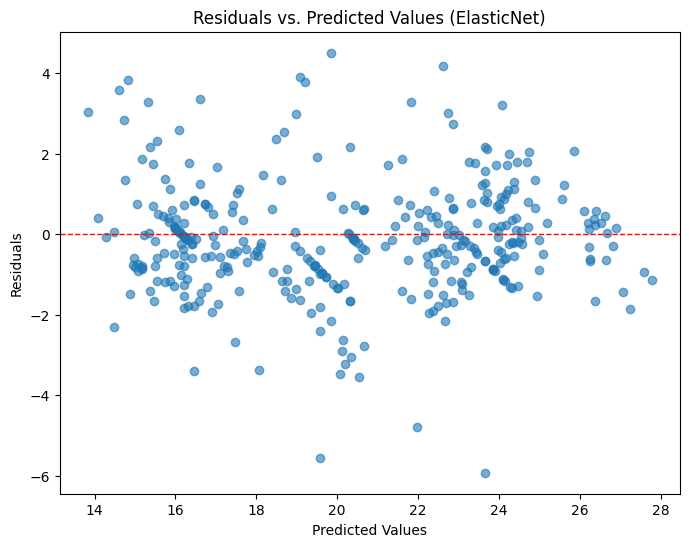

In [ ]:
get_residuals_vs_pred_plot(model_predictions = elasticnet_predictions, model_name = 'ElasticNet')

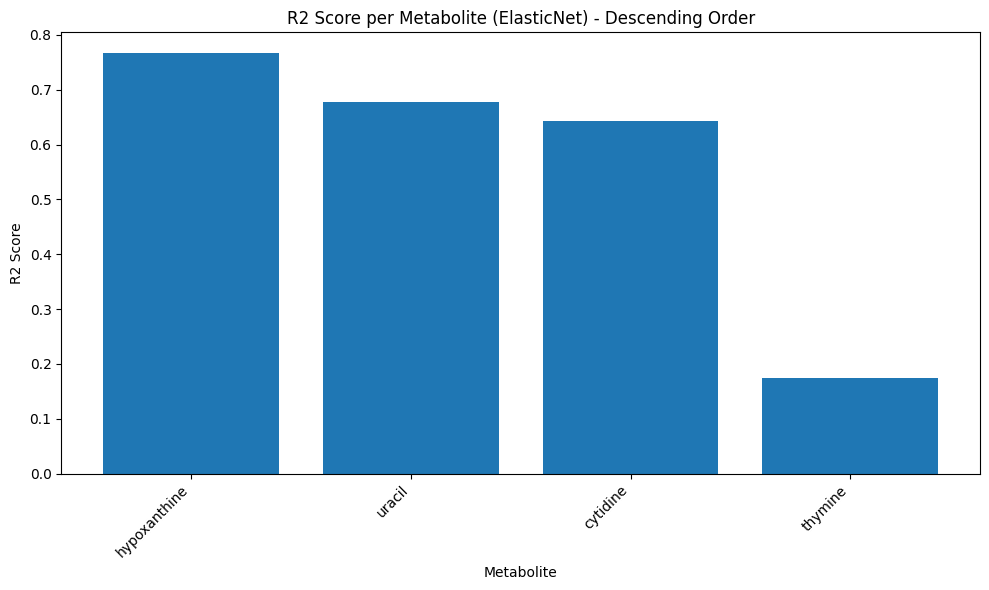

In [ ]:
plot_r2_per_metabolite(best_elasticnet_model, "ElasticNet", X_test, y_test)

In [ ]:
y_test.to_csv(f'{results_path}/y_test_elasticnet_model.csv', index = True)

In [ ]:
elasticnet_predictions = pd.DataFrame(elasticnet_predictions, index = y_test.index, columns = y_test.columns)
elasticnet_predictions

,thymine,uracil,cytidine,hypoxanthine
MSKC-00424,15.743474,23.705703,19.347577,25.559208
DIAG-16158,16.462022,23.070690,17.469064,21.975716
MSKC-00352,16.508641,23.990370,21.804683,26.105883
MSKC-00406,16.470244,22.322660,18.492457,22.621209
MSKC-00481,15.925886,24.536435,18.945256,24.129889
...,...,...,...,...
MSKC-00444,15.231547,24.184712,18.403815,24.015483
MSKC-00635,15.553149,23.254252,21.431494,24.894711
DIAG-16124,15.043135,22.239484,16.293949,20.347641
CORN-02050,17.033226,22.401257,15.005873,18.756592


In [ ]:
elasticnet_predictions.to_csv(f'{results_path}/predictions_elasticnet_model.csv', index = True)

In [ ]:
r2_elastic = get_r2_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)
r2_elastic

,Metabolite,R2 Score
3,hypoxanthine,0.766207
1,uracil,0.677069
2,cytidine,0.643755
0,thymine,0.175208


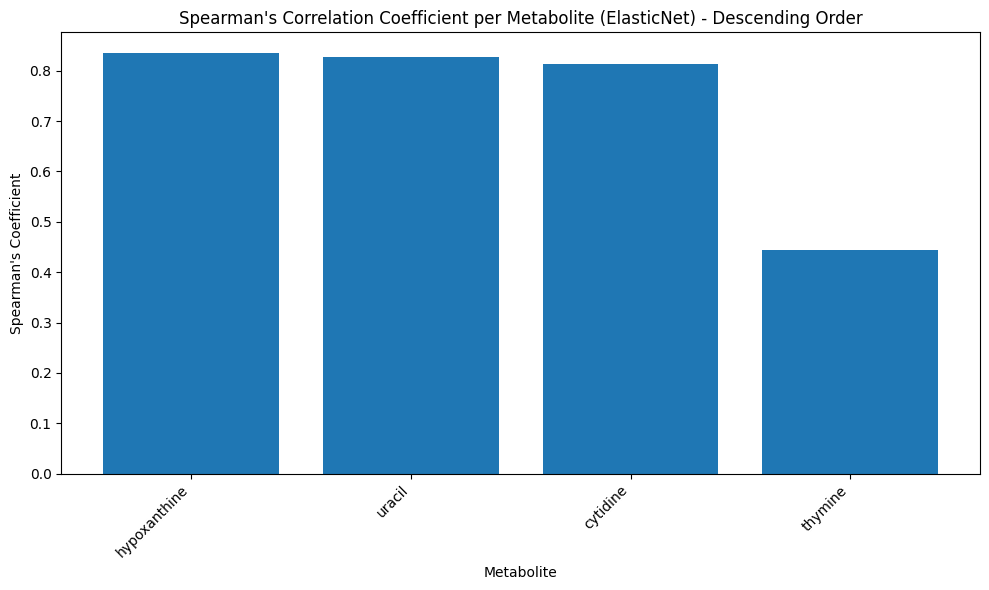

In [ ]:
plot_spearman_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)

In [ ]:
spearman_elastic = get_spearman_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)
spearman_elastic

,Metabolite,Spearman Coefficient
3,hypoxanthine,0.834320
1,uracil,0.827382
2,cytidine,0.813645
0,thymine,0.443154


In [ ]:
r2_elastic.to_csv(f'{results_path}/r2_elastic.csv', index = False)
spearman_elastic.to_csv(f'{results_path}/spearman_elastic.csv', index = False)

#Error estimation


### 1. Conformal Prediction (MAPIE)


In [ ]:
# target_metabolite = 'thymine'
# y_train_single = y_train[target_metabolite]
# y_test_single = y_test[target_metabolite]

In [ ]:
!pip install mapie -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.6/555.6 kB 9.7 MB/s eta 0:00:00



--- Running MAPIE Conformal Prediction for thymine ---
MAPIE Conformal Prediction for 'thymine' (90% CI):
Coverage: 0.944
Mean Width: 4.121


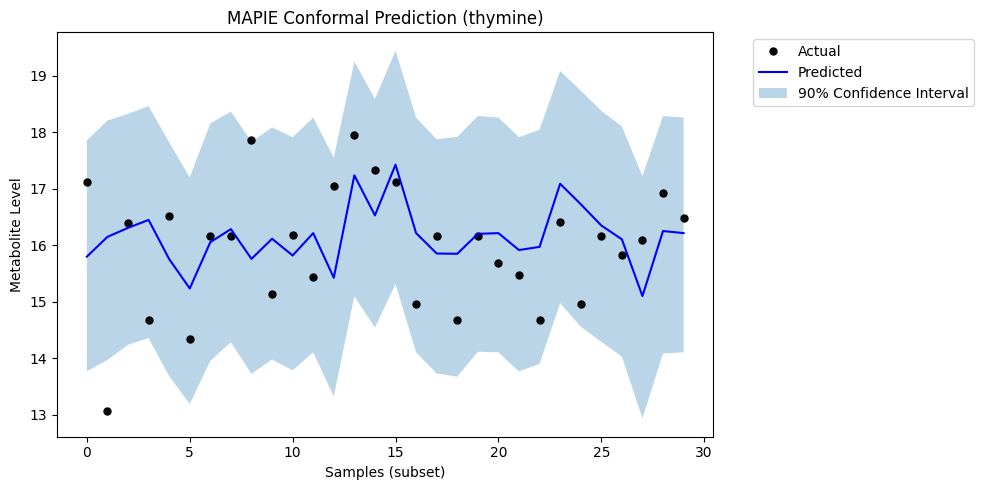


--- Running MAPIE Conformal Prediction for uracil ---
MAPIE Conformal Prediction for 'uracil' (90% CI):
Coverage: 0.876
Mean Width: 2.981


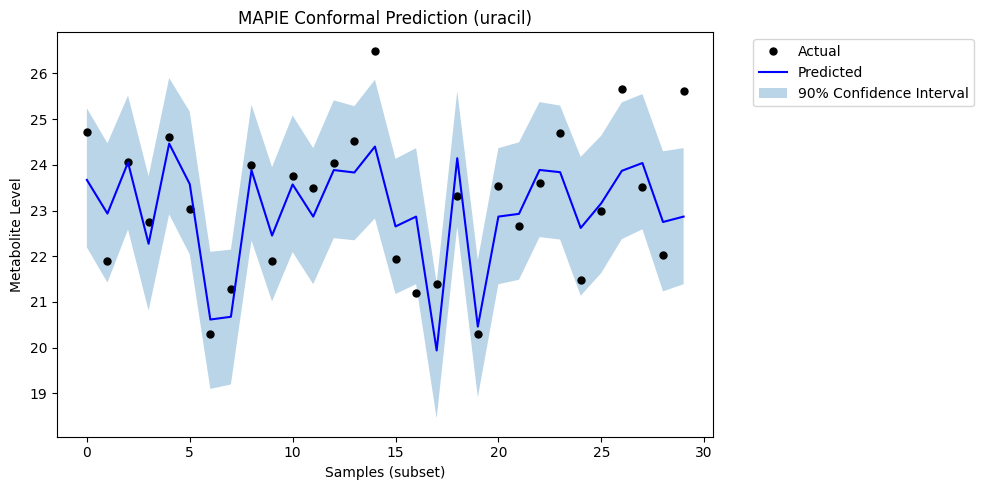


--- Running MAPIE Conformal Prediction for cytidine ---
MAPIE Conformal Prediction for 'cytidine' (90% CI):
Coverage: 0.944
Mean Width: 6.641


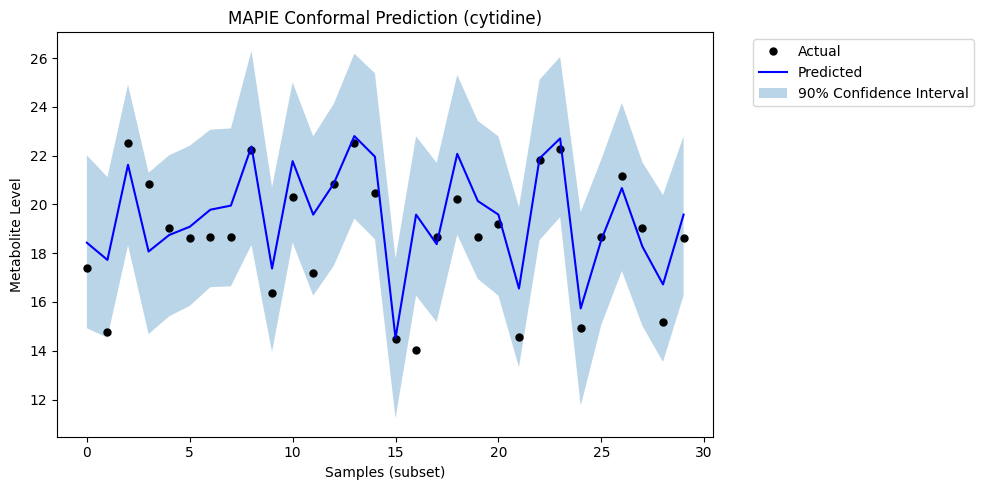


--- Running MAPIE Conformal Prediction for hypoxanthine ---
MAPIE Conformal Prediction for 'hypoxanthine' (90% CI):
Coverage: 0.899
Mean Width: 6.545


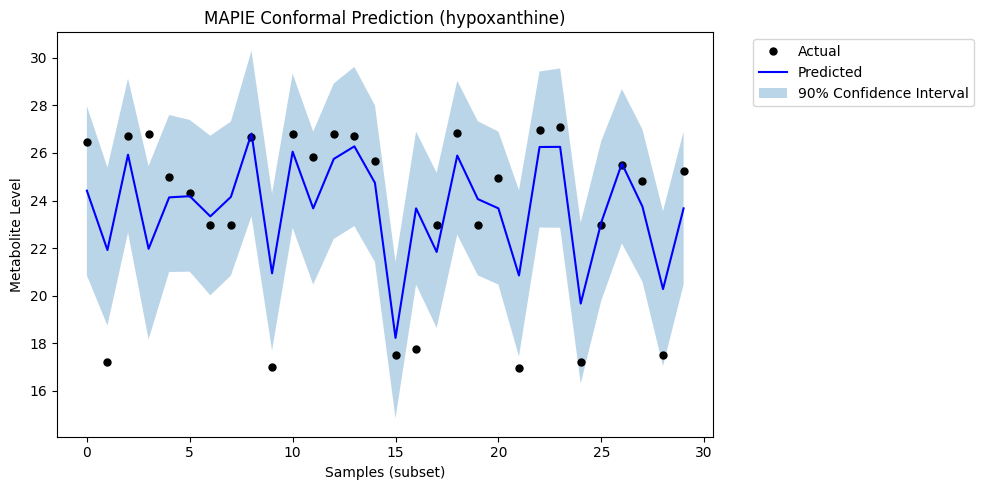

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mapie.regression import CrossConformalRegressor
from mapie.metrics.regression import regression_coverage_score, regression_mean_width_score
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


base_estimator = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', ElasticNet(alpha=1, l1_ratio=0.1, random_state=0))
])

confidence_level = 0.90

for target_metabolite in nucleotides_names:
    print(f"\n--- Running MAPIE Conformal Prediction for {target_metabolite} ---")
    y_train_single = y_train[target_metabolite]
    y_test_single = y_test[target_metabolite]


    mapie_reg = CrossConformalRegressor(
        estimator=base_estimator,
        cv=5,
        confidence_level=confidence_level,
        n_jobs=-1
    )


    mapie_reg.fit_conformalize(X_train, y_train_single)


    y_pred_mapie, y_pis = mapie_reg.predict_interval(X_test)


    coverage = regression_coverage_score(y_test_single, y_pis)[0]
    width = regression_mean_width_score(y_pis)[0]

    print(f"MAPIE Conformal Prediction for '{target_metabolite}' ({confidence_level*100:.0f}% CI):")
    print(f"Coverage: {coverage:.3f}")
    print(f"Mean Width: {width:.3f}")


    y_lower_mapie = y_pis[:, 0, 0]
    y_upper_mapie = y_pis[:, 1, 0]


    plt.figure(figsize=(10, 5))
    x_ax = np.arange(30)
    plt.plot(x_ax, y_test_single[:30], 'ko', markersize=5, label='Actual')
    plt.plot(x_ax, y_pred_mapie[:30], 'b-', label='Predicted')
    plt.fill_between(x_ax, y_lower_mapie[:30], y_upper_mapie[:30], alpha=0.3, label=f'{confidence_level*100:.0f}% Confidence Interval')
    plt.xlabel('Samples (subset)')
    plt.ylabel('Metabolite Level')
    plt.title(f'MAPIE Conformal Prediction ({target_metabolite})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{results_path}/MAPIE ({target_metabolite}).svg', bbox_inches = 'tight')
    plt.show()


### 2. Quantile Regression (scikit-learn)


--- Running Quantile Regression for thymine ---
Fitting QuantileRegressor for quantile 0.05...
Fitting QuantileRegressor for quantile 0.5...
Fitting QuantileRegressor for quantile 0.95...

Quantile Regression for 'thymine' (90% CI):
Coverage: 0.843
Mean Width: 3.244


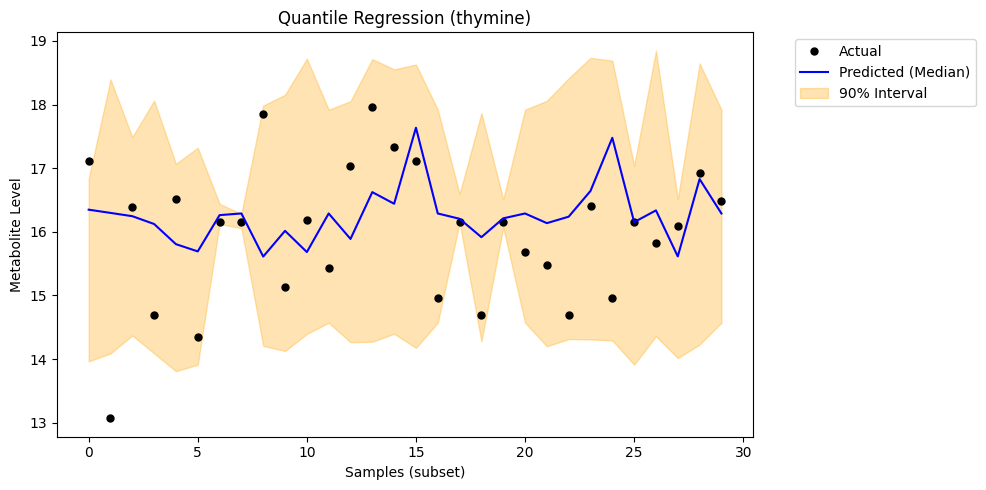


--- Running Quantile Regression for uracil ---
Fitting QuantileRegressor for quantile 0.05...
Fitting QuantileRegressor for quantile 0.5...
Fitting QuantileRegressor for quantile 0.95...

Quantile Regression for 'uracil' (90% CI):
Coverage: 0.854
Mean Width: 3.075


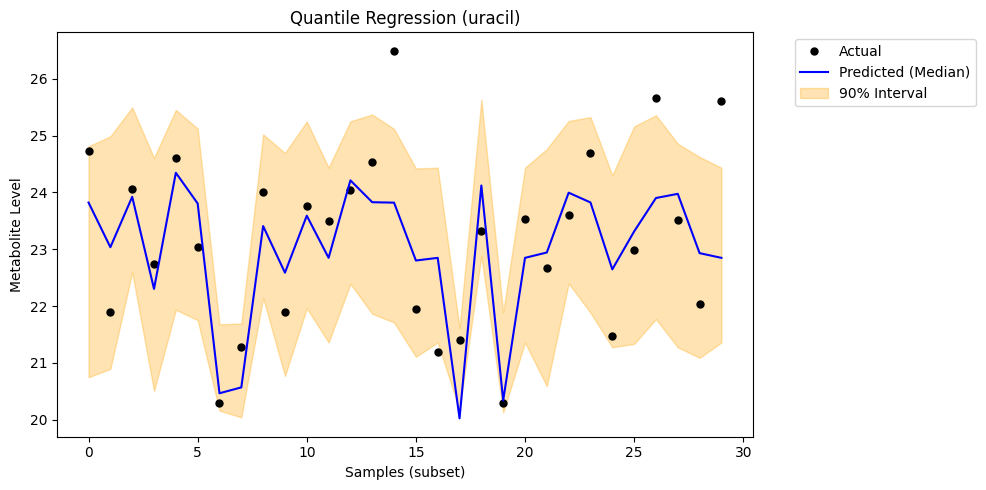


--- Running Quantile Regression for cytidine ---
Fitting QuantileRegressor for quantile 0.05...
Fitting QuantileRegressor for quantile 0.5...
Fitting QuantileRegressor for quantile 0.95...

Quantile Regression for 'cytidine' (90% CI):
Coverage: 0.798
Mean Width: 6.218


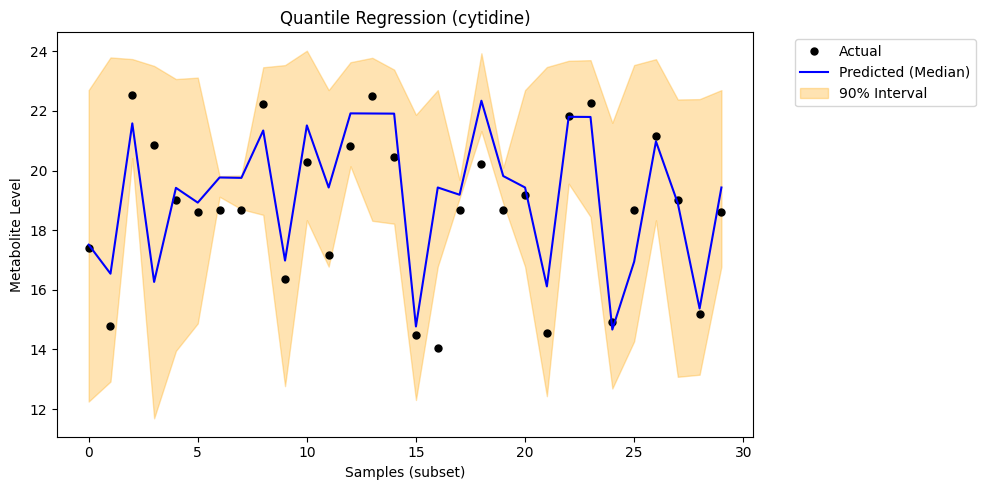


--- Running Quantile Regression for hypoxanthine ---
Fitting QuantileRegressor for quantile 0.05...
Fitting QuantileRegressor for quantile 0.5...
Fitting QuantileRegressor for quantile 0.95...

Quantile Regression for 'hypoxanthine' (90% CI):
Coverage: 0.787
Mean Width: 5.930


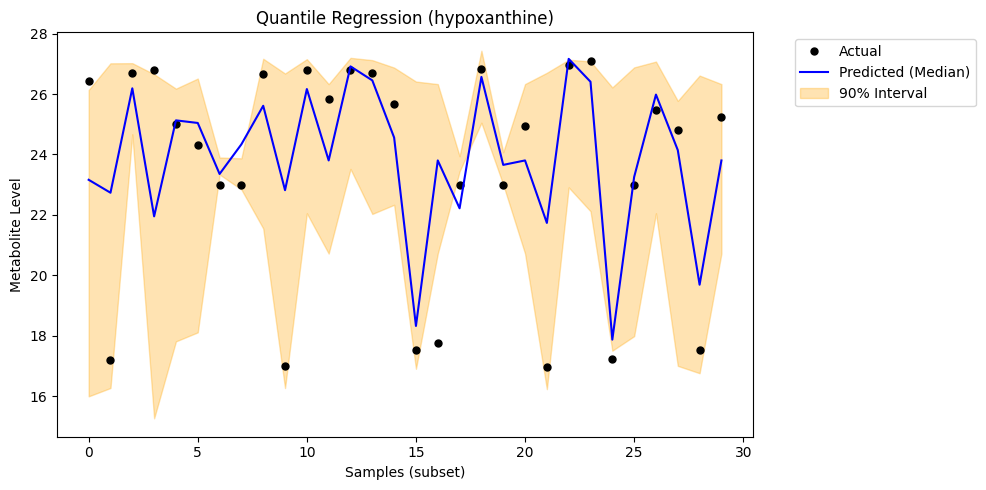

In [ ]:
from sklearn.linear_model import QuantileRegressor

#Predict the 5th, 50th (median), and 95th percentiles (90% Confidence Interval)
quantiles = [0.05, 0.5, 0.95]

for target_metabolite in nucleotides_names:
    print(f"\n--- Running Quantile Regression for {target_metabolite} ---")
    y_train_single = y_train[target_metabolite]
    y_test_single = y_test[target_metabolite]

    predictions_qr = {}

    for q in quantiles:
        print(f"Fitting QuantileRegressor for quantile {q}...")

        qr_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('pca', PCA(0.95)),
            ('model', QuantileRegressor(quantile=q, alpha=0.1, solver='highs'))
        ])
        qr_pipeline.fit(X_train, y_train_single)
        predictions_qr[q] = qr_pipeline.predict(X_test)


    y_lower_qr = predictions_qr[0.05]
    y_pred_qr = predictions_qr[0.5]
    y_upper_qr = predictions_qr[0.95]


    coverage_qr = np.mean((y_test_single >= y_lower_qr) & (y_test_single <= y_upper_qr))
    width_qr = np.mean(y_upper_qr - y_lower_qr)

    print(f"\nQuantile Regression for '{target_metabolite}' (90% CI):")
    print(f"Coverage: {coverage_qr:.3f}")
    print(f"Mean Width: {width_qr:.3f}")


    plt.figure(figsize=(10, 5))
    x_ax = np.arange(30)
    plt.plot(x_ax, y_test_single[:30], 'ko', markersize=5, label='Actual')
    plt.plot(x_ax, y_pred_qr[:30], 'b-', label='Predicted (Median)')
    plt.fill_between(x_ax, y_lower_qr[:30], y_upper_qr[:30], alpha=0.3, color='orange', label='90% Interval')
    plt.xlabel('Samples (subset)')
    plt.ylabel('Metabolite Level')
    plt.title(f'Quantile Regression ({target_metabolite})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{results_path}/QR ({target_metabolite}).svg', bbox_inches = 'tight')
    plt.show()


#Model explanation

##Mutual Information


--- Top 10 Features by Mutual Information for thymine ---


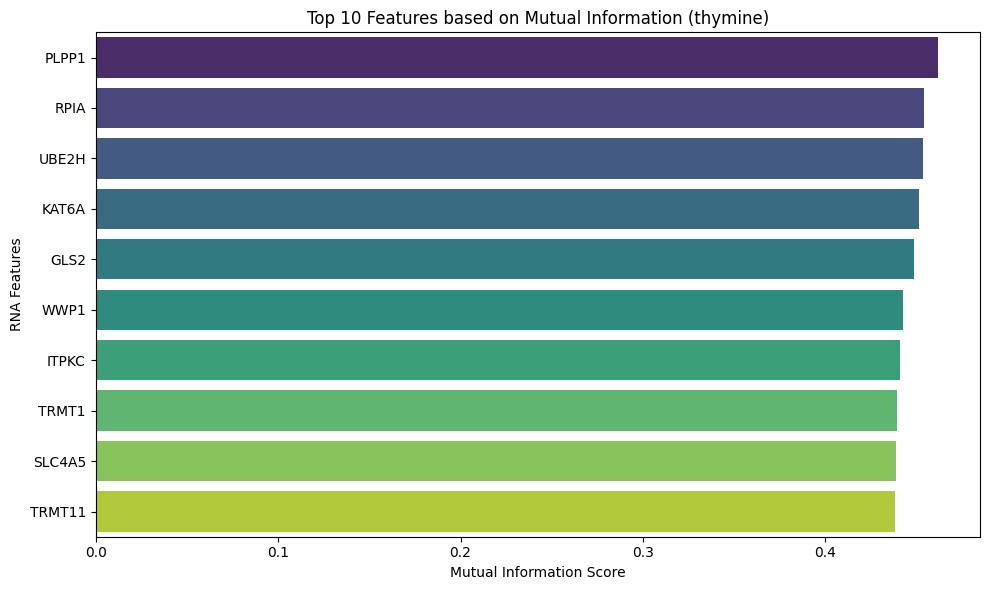


--- Top 10 Features by Mutual Information for uracil ---


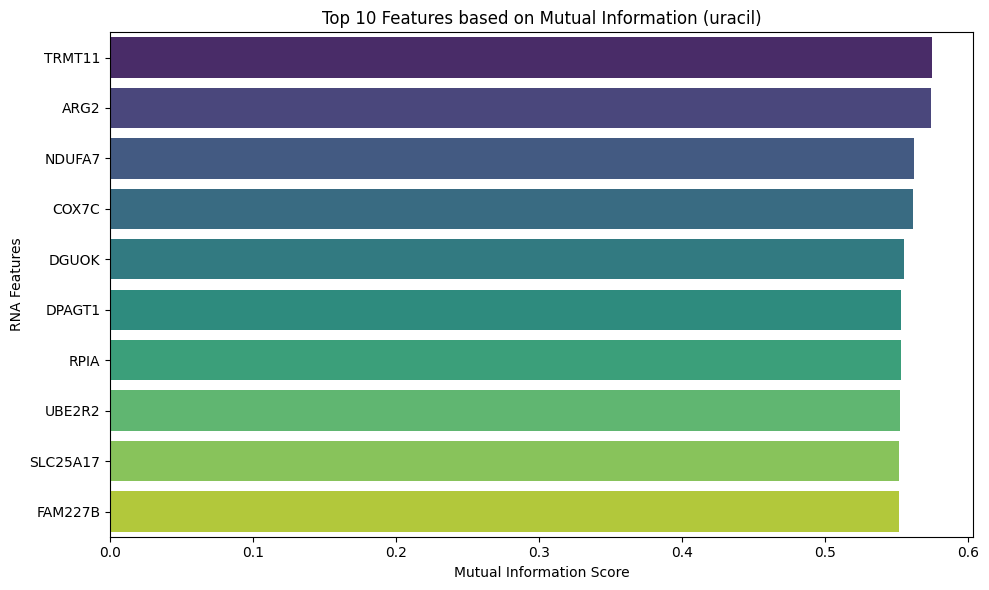


--- Top 10 Features by Mutual Information for cytidine ---


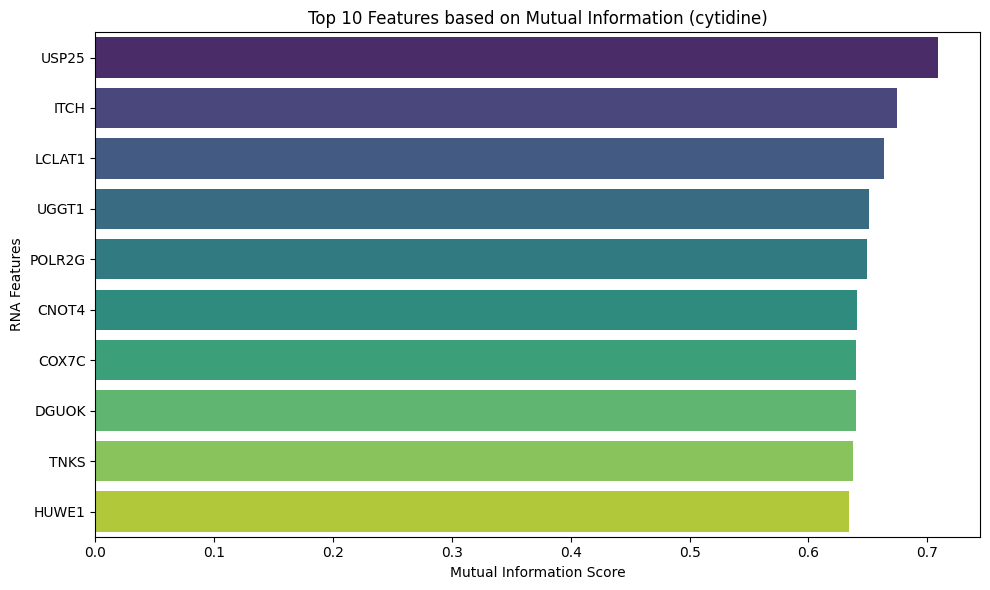


--- Top 10 Features by Mutual Information for hypoxanthine ---


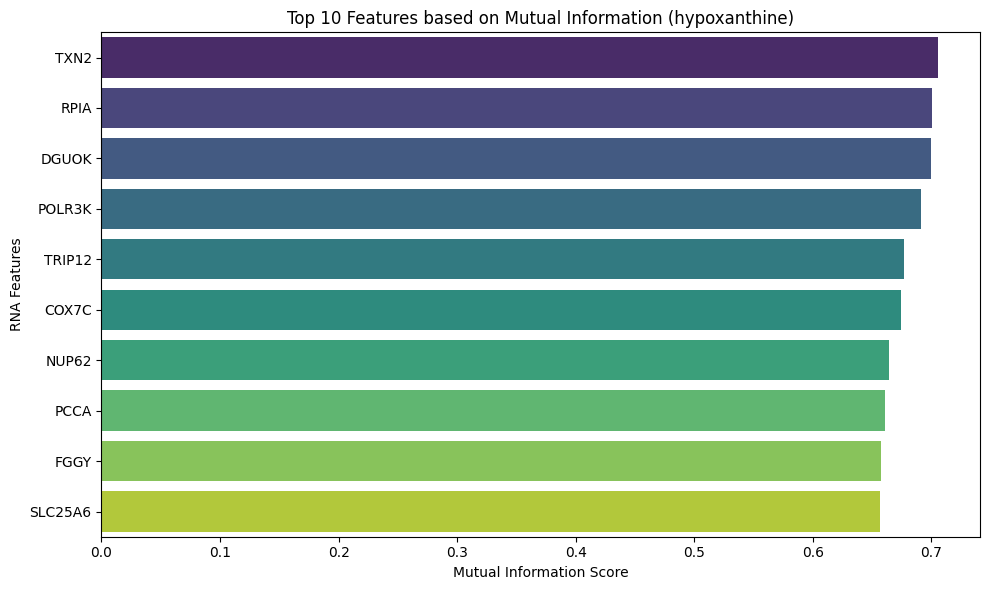

In [ ]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

for metabolite in nucleotides_names:
    print(f"\n--- Top 10 Features by Mutual Information for {metabolite} ---")
    y_train_target = y_train[metabolite]


    mi_scores = mutual_info_regression(X_train_imputed, y_train_target, random_state=0)
    mi_scores_series = pd.Series(mi_scores, index=X_train.columns)


    top_10_mi = mi_scores_series.sort_values(ascending=False).head(10)


    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_10_mi.values, y=top_10_mi.index, hue=top_10_mi.index, legend=False, palette='viridis')
    plt.title(f'Top 10 Features based on Mutual Information ({metabolite})')
    plt.xlabel('Mutual Information Score')
    plt.ylabel('RNA Features')
    plt.tight_layout()
    plt.savefig(f'{results_path}/Mutual Information ({metabolite}).svg', bbox_inches = 'tight')
    plt.show()


##ReliefF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.2 MB/s eta 0:00:00

--- Top 10 Features by ReliefF for thymine ---


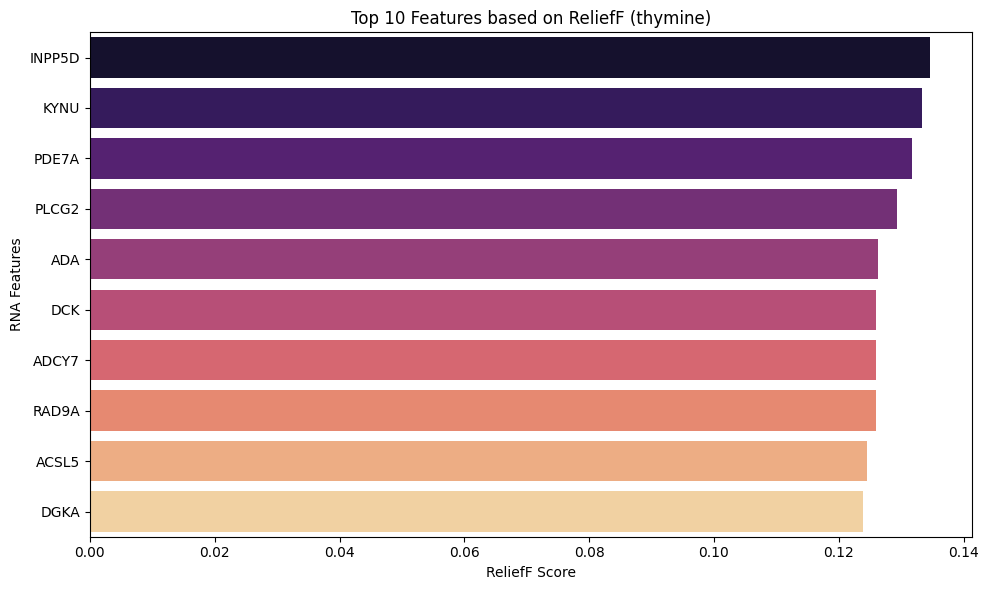


--- Top 10 Features by ReliefF for uracil ---


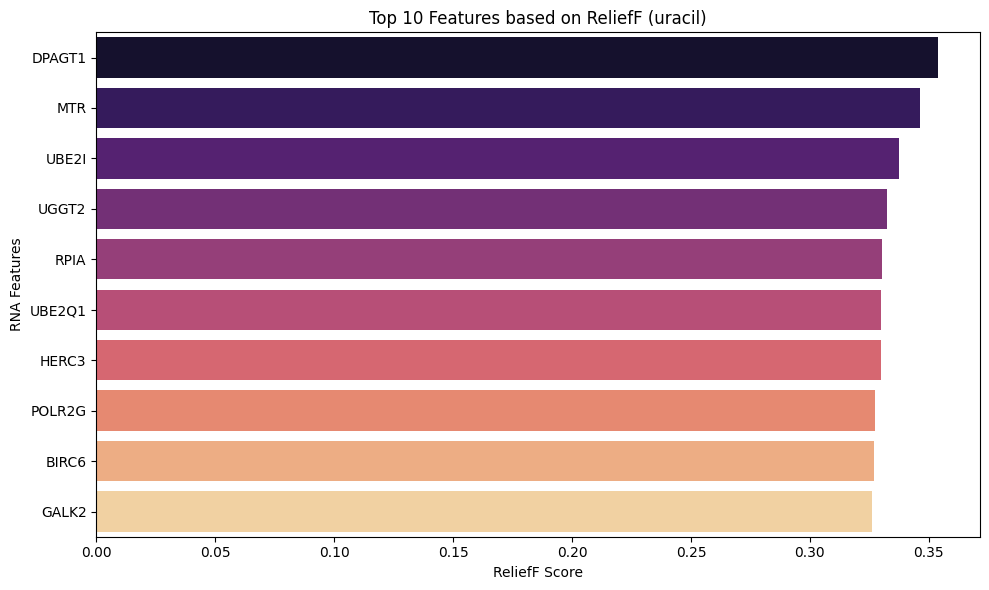


--- Top 10 Features by ReliefF for cytidine ---


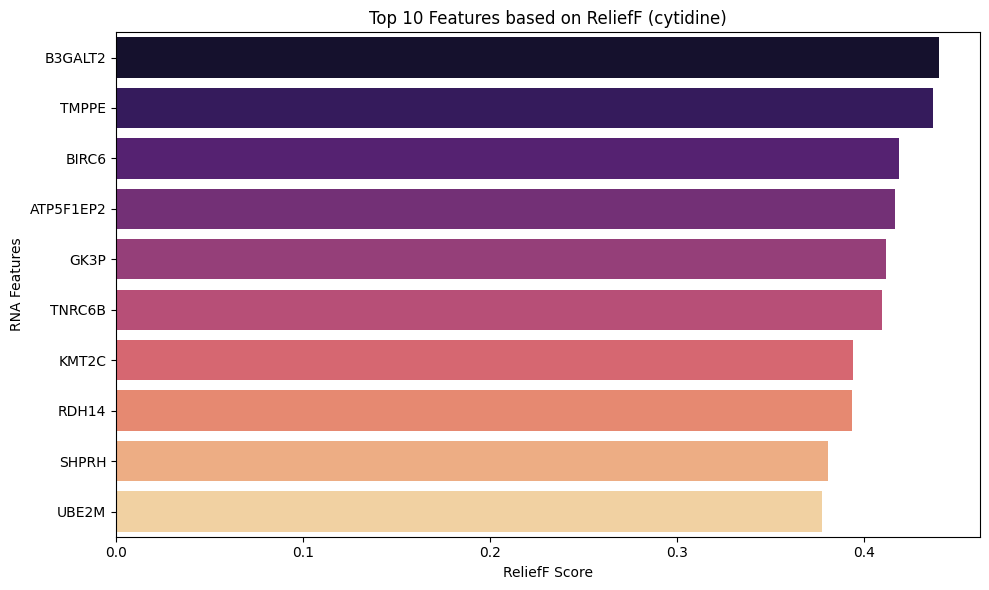


--- Top 10 Features by ReliefF for hypoxanthine ---


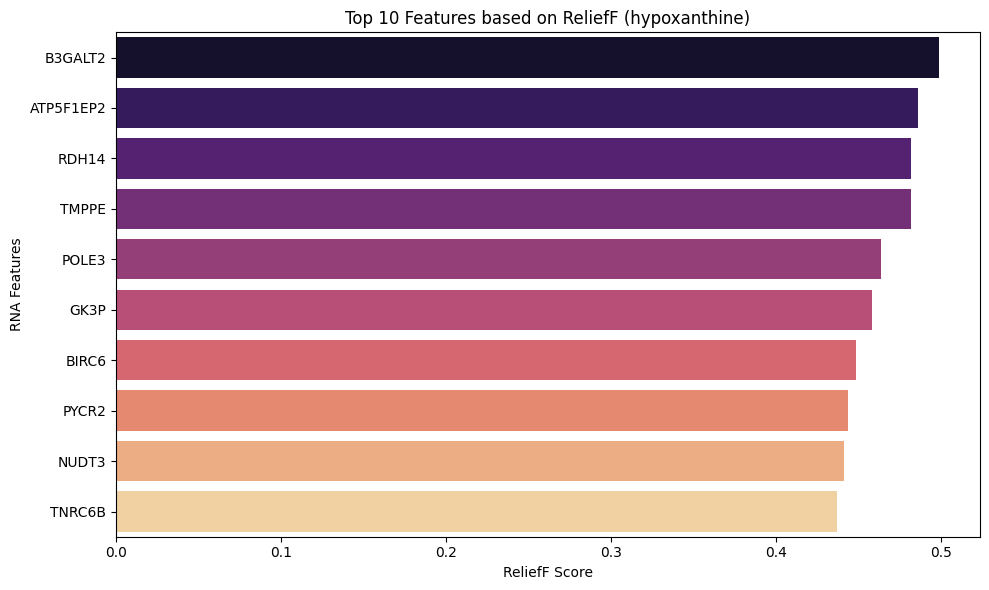

In [ ]:
!pip install skrebate

from skrebate import ReliefF
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

for metabolite in nucleotides_names:
    print(f"\n--- Top 10 Features by ReliefF for {metabolite} ---")
    y_train_target = y_train[metabolite].values


    rrf = ReliefF(n_features_to_select=10, n_neighbors=100, n_jobs=-1)


    rrf.fit(X_train_imputed, y_train_target)


    rrf_scores_series = pd.Series(rrf.feature_importances_, index=X_train.columns)


    top_10_rrf = rrf_scores_series.sort_values(ascending=False).head(10)


    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_10_rrf.values, y=top_10_rrf.index, hue=top_10_rrf.index, legend=False, palette='magma')
    plt.title(f'Top 10 Features based on ReliefF ({metabolite})')
    plt.xlabel('ReliefF Score')
    plt.ylabel('RNA Features')
    plt.tight_layout()
    plt.savefig(f'{results_path}/ReliefF ({metabolite}).svg', bbox_inches = 'tight')
    plt.show()


--- Calculating and plotting overlap for thymine ---


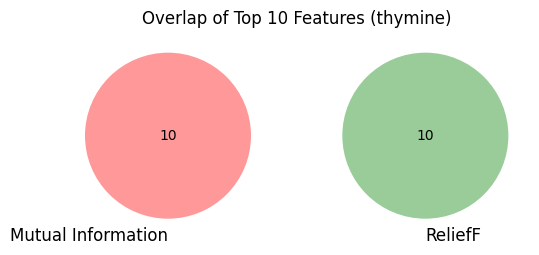

No overlapping features.

--- Calculating and plotting overlap for uracil ---


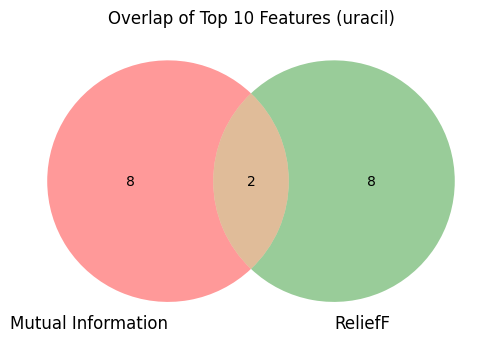

Overlapping features: DPAGT1, RPIA

--- Calculating and plotting overlap for cytidine ---


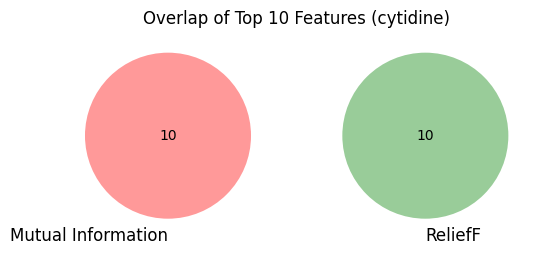

No overlapping features.

--- Calculating and plotting overlap for hypoxanthine ---


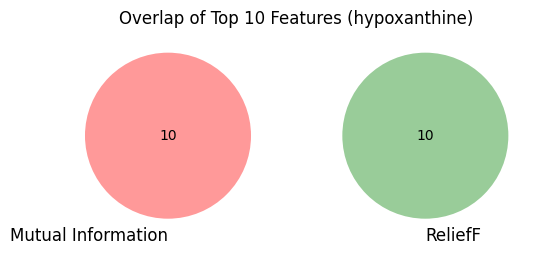

No overlapping features.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from sklearn.feature_selection import mutual_info_regression
from skrebate import ReliefF
from sklearn.impute import SimpleImputer
import pandas as pd


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

for metabolite in nucleotides_names:
    print(f"\n--- Calculating and plotting overlap for {metabolite} ---")
    y_train_target = y_train[metabolite].values


    mi_scores = mutual_info_regression(X_train_imputed, y_train_target, random_state=0)
    mi_scores_series = pd.Series(mi_scores, index=X_train.columns)
    top_10_mi_set = set(mi_scores_series.sort_values(ascending=False).head(10).index)


    rrf = ReliefF(n_features_to_select=10, n_neighbors=100, n_jobs=-1)
    rrf.fit(X_train_imputed, y_train_target)
    rrf_scores_series = pd.Series(rrf.feature_importances_, index=X_train.columns)
    top_10_rrf_set = set(rrf_scores_series.sort_values(ascending=False).head(10).index)


    plt.figure(figsize=(6, 6))
    venn = venn2([top_10_mi_set, top_10_rrf_set], ('Mutual Information', 'ReliefF'))
    plt.title(f'Overlap of Top 10 Features ({metabolite})')
    plt.savefig(f'{results_path}/Overlap ({metabolite}).svg', bbox_inches = 'tight')
    plt.show()


    overlap = top_10_mi_set.intersection(top_10_rrf_set)
    if overlap:
        print(f"Overlapping features: {', '.join(overlap)}")
    else:
        print("No overlapping features.")


##Feature Importance


--- Top 10 Features for Multi-output Model ---


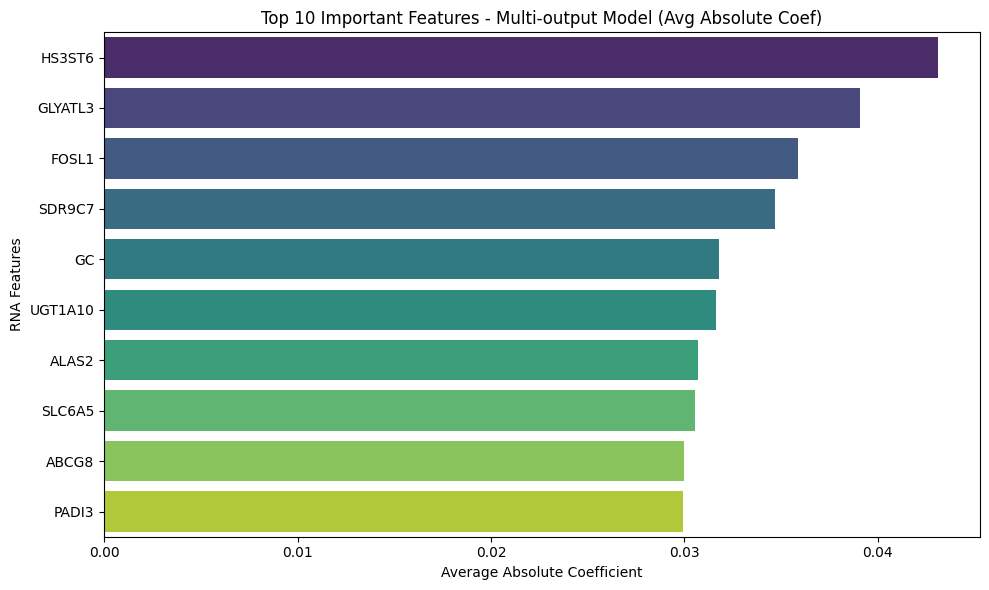


--- Top 10 Features for thymine ---


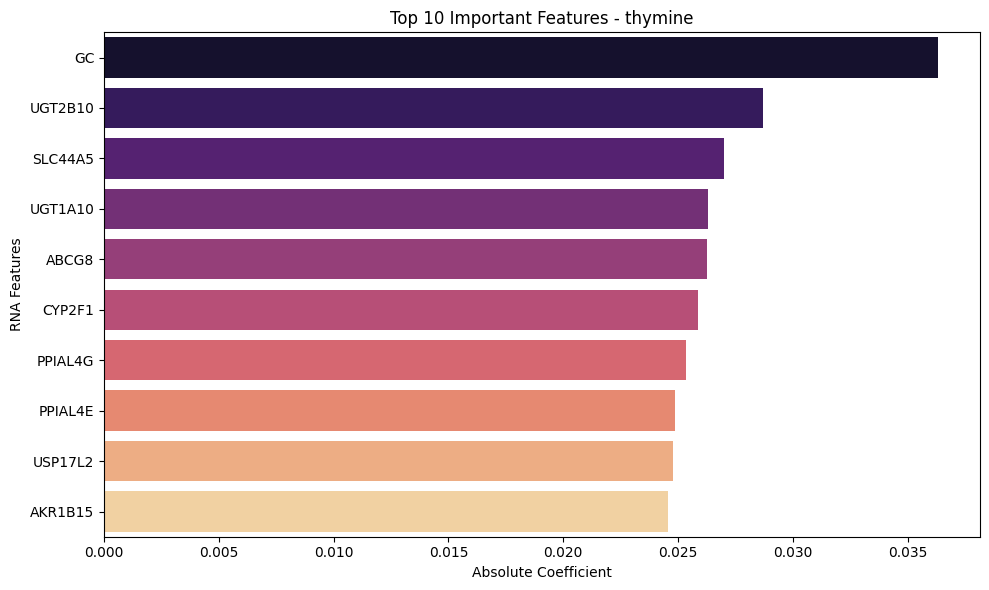


--- Top 10 Features for uracil ---


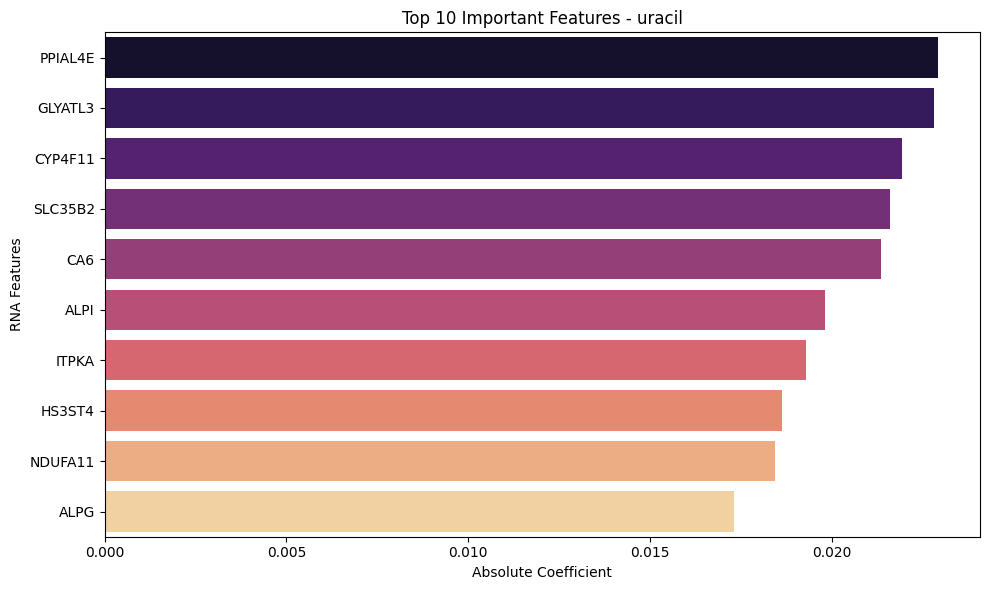


--- Top 10 Features for cytidine ---


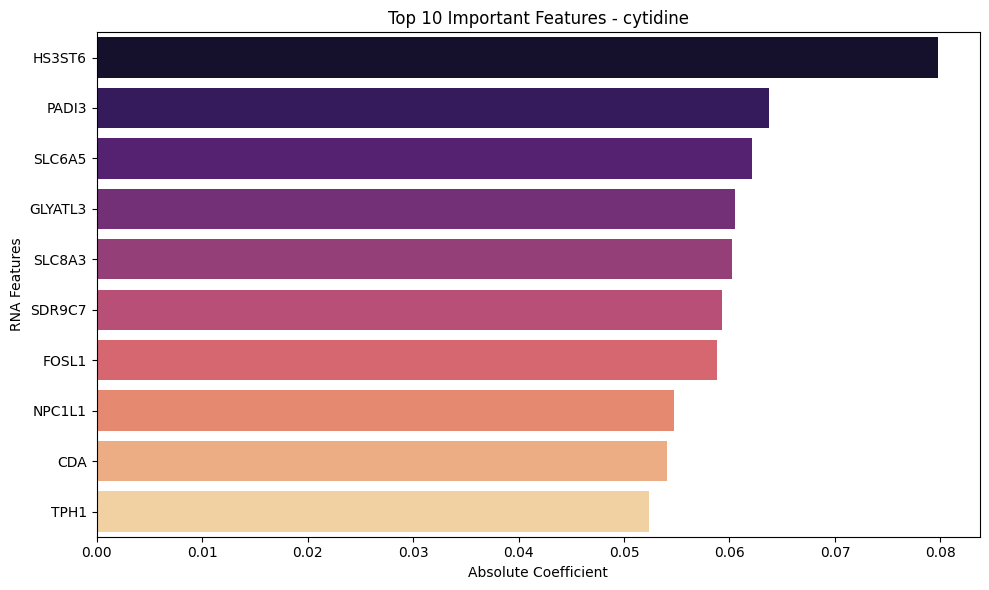


--- Top 10 Features for hypoxanthine ---


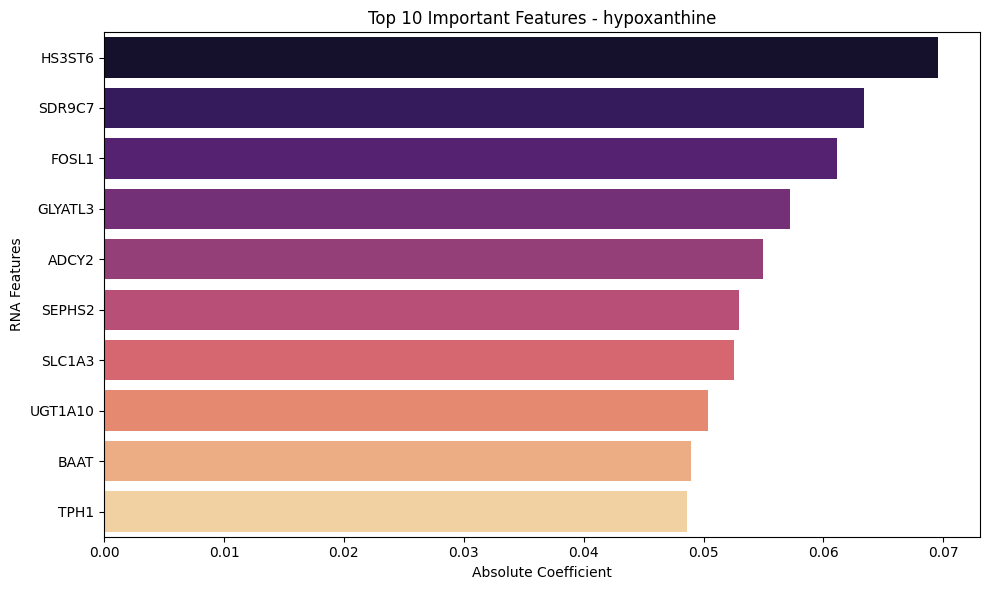

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pca = best_elasticnet_model.named_steps['pca']
model = best_elasticnet_model.named_steps['model']

# model.coef_ shape: (n_targets, n_components)
# pca.components_ shape: (n_components, n_features)
original_coefs = model.coef_ @ pca.components_


coef_df = pd.DataFrame(original_coefs.T, index=X_train.columns, columns=y_train.columns)

# 1. Multi-output Feature Importance (Average absolute coefficient across all metabolites)
print("\n--- Top 10 Features for Multi-output Model ---")
multi_importance = coef_df.abs().mean(axis=1).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=multi_importance.values, y=multi_importance.index, hue=multi_importance.index, legend=False, palette='viridis')
plt.title('Top 10 Important Features - Multi-output Model (Avg Absolute Coef)')
plt.xlabel('Average Absolute Coefficient')
plt.ylabel('RNA Features')
plt.tight_layout()
plt.savefig(f'{results_path}/Multi-output Feature Importance.svg', bbox_inches = 'tight')
plt.show()

# 2. Single Feature Importance per Nucleotide
for metabolite in y_train.columns:
    print(f"\n--- Top 10 Features for {metabolite} ---")
    single_importance = coef_df[metabolite].abs().sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=single_importance.values, y=single_importance.index, hue=single_importance.index, legend=False, palette='magma')
    plt.title(f'Top 10 Important Features - {metabolite}')
    plt.xlabel('Absolute Coefficient')
    plt.ylabel('RNA Features')
    plt.tight_layout()
    plt.savefig(f'{results_path}/Single Feature Importance ({metabolite}).svg', bbox_inches = 'tight')
    plt.show()



--- Overlap for Multi-output vs Single Model (thymine) ---


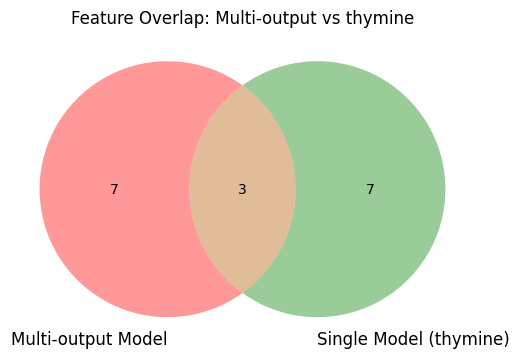

Overlapping features: UGT1A10, ABCG8, GC

--- Overlap for Multi-output vs Single Model (uracil) ---


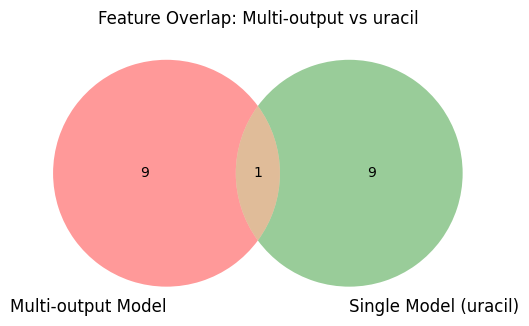

Overlapping features: GLYATL3

--- Overlap for Multi-output vs Single Model (cytidine) ---


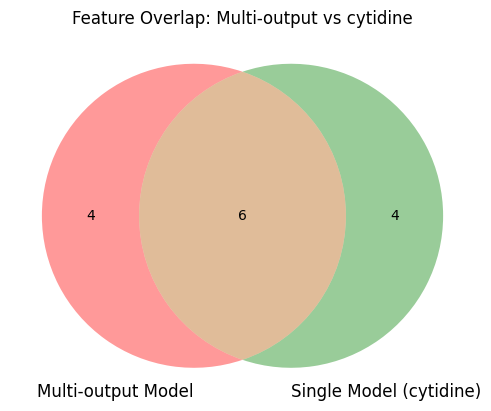

Overlapping features: SDR9C7, FOSL1, GLYATL3, PADI3, SLC6A5, HS3ST6

--- Overlap for Multi-output vs Single Model (hypoxanthine) ---


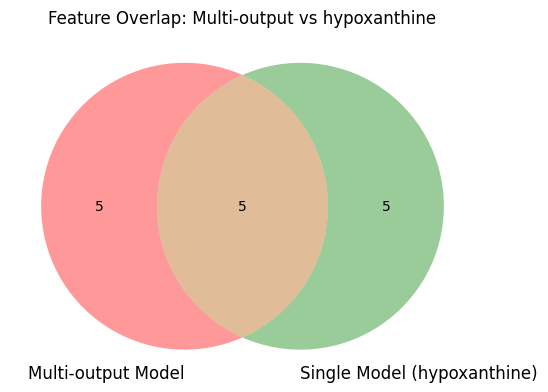

Overlapping features: SDR9C7, FOSL1, GLYATL3, UGT1A10, HS3ST6


In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


multi_output_top10 = set(coef_df.abs().mean(axis=1).sort_values(ascending=False).head(10).index)


for metabolite in y_train.columns:
    print(f"\n--- Overlap for Multi-output vs Single Model ({metabolite}) ---")


    single_model_top10 = set(coef_df[metabolite].abs().sort_values(ascending=False).head(10).index)


    plt.figure(figsize=(6, 6))
    venn2([multi_output_top10, single_model_top10], ('Multi-output Model', f'Single Model ({metabolite})'))
    plt.title(f'Feature Overlap: Multi-output vs {metabolite}')
    plt.savefig(f'{results_path}/Feature Overlap ({metabolite}).svg', bbox_inches = 'tight')
    plt.show()


    overlap = multi_output_top10.intersection(single_model_top10)
    if overlap:
        print(f"Overlapping features: {', '.join(overlap)}")
    else:
        print("No overlapping features.")


##SHAP


--- Top 10 Features by SHAP for Multi-output Model ---


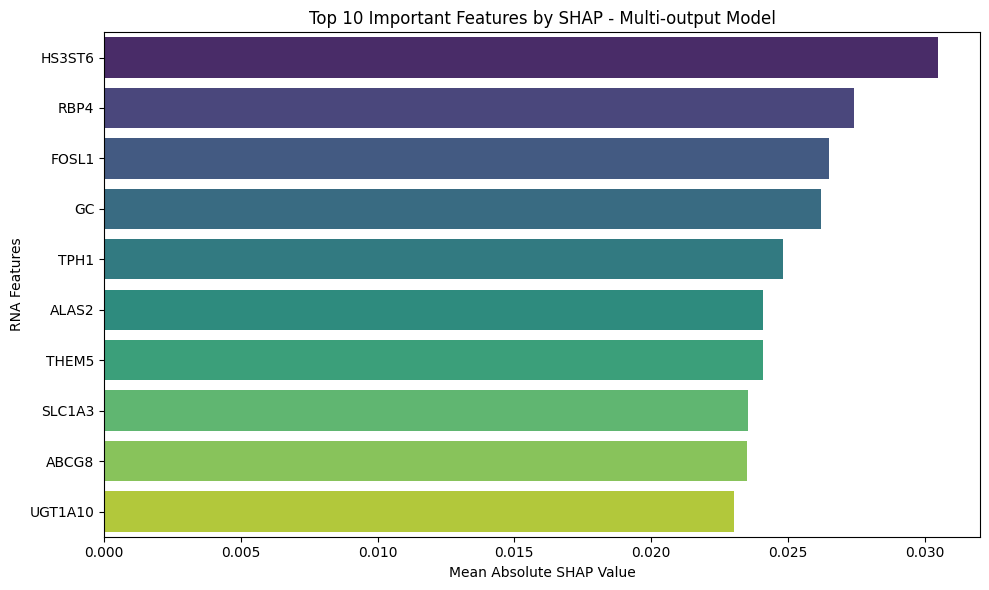


--- Top 10 Features by SHAP for thymine ---


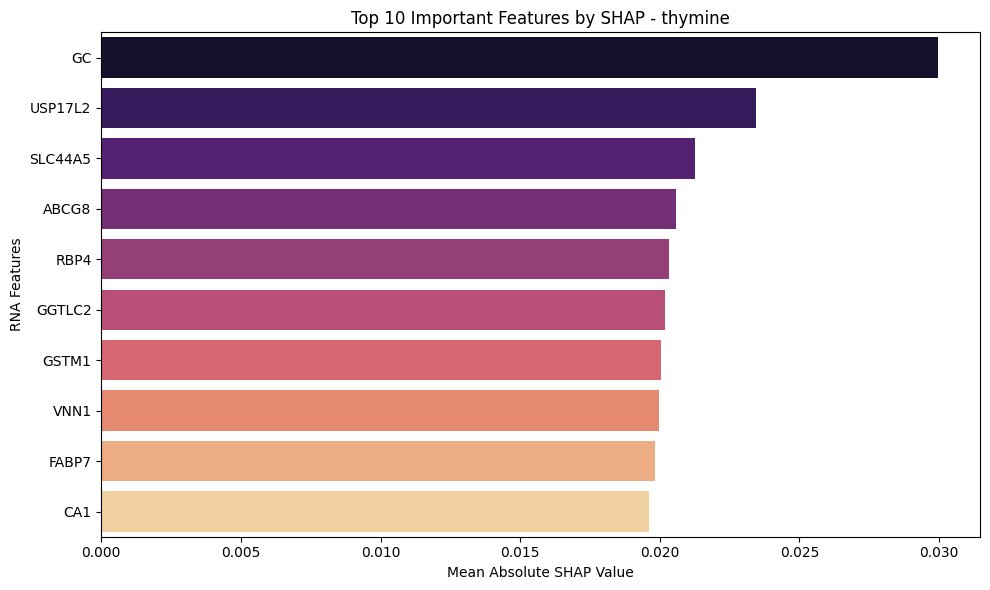


--- Top 10 Features by SHAP for uracil ---


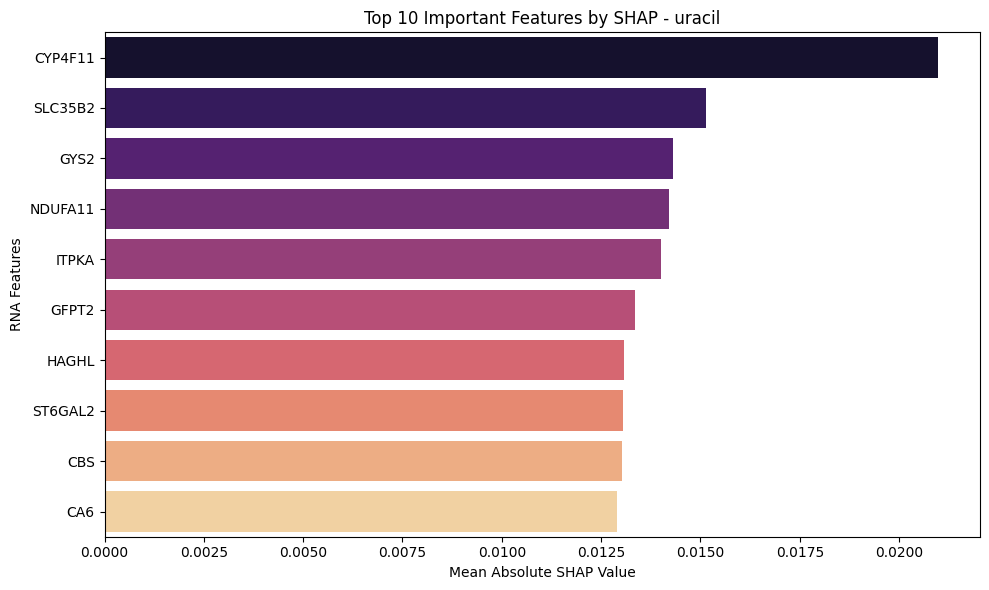


--- Top 10 Features by SHAP for cytidine ---


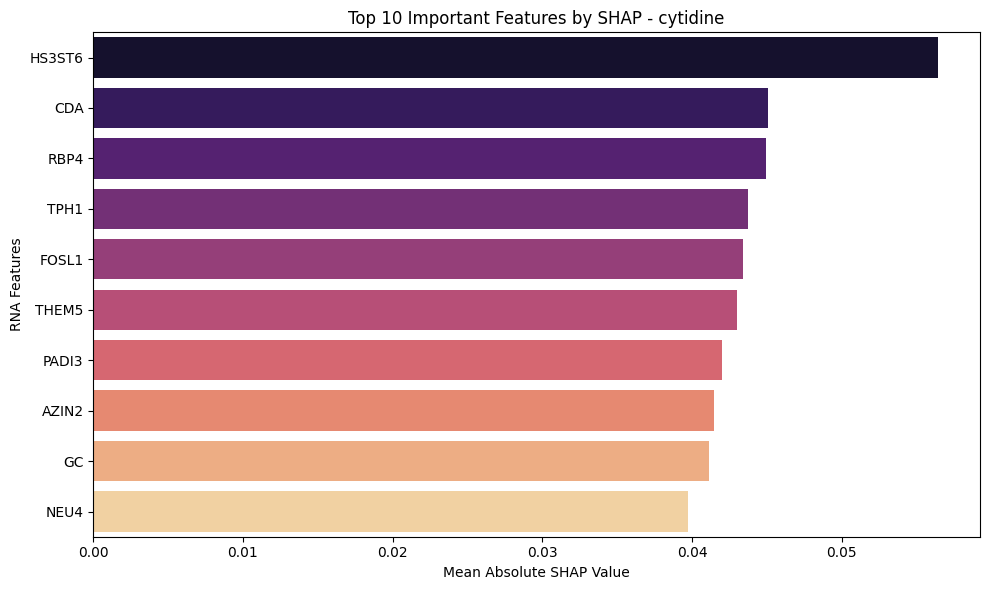


--- Top 10 Features by SHAP for hypoxanthine ---


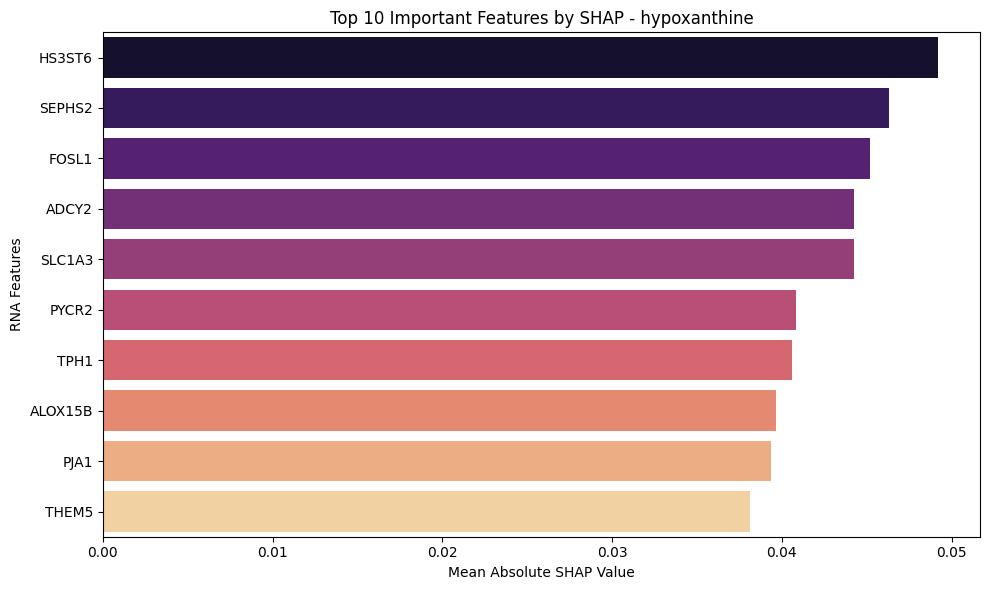

In [ ]:
!pip install shap
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Transform the test data to the scaled space to calculate SHAP properly
imputer = best_elasticnet_model.named_steps['imputer']
scaler = best_elasticnet_model.named_steps['scaler']

X_test_imputed = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)

# SHAP values for a linear model: phi_ij = (X_ij - E[X_j]) * w_j
# Since StandardScaler centers to 0, E[X_j] is approximately 0.
shap_values_dict = {}
mean_abs_shap_dict = {}

for idx, metabolite in enumerate(y_train.columns):
    # Calculate SHAP values for each sample and feature
    shap_vals = X_test_scaled * original_coefs[idx, :]
    shap_values_dict[metabolite] = shap_vals

    # Calculate mean absolute SHAP value for each feature
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    mean_abs_shap_dict[metabolite] = pd.Series(mean_abs_shap, index=X_test.columns)

# Combine to get Multi-output model SHAP importance (average across all targets)
df_mean_abs_shap = pd.DataFrame(mean_abs_shap_dict)
multi_shap_importance = df_mean_abs_shap.mean(axis=1).sort_values(ascending=False).head(10)

print("\n--- Top 10 Features by SHAP for Multi-output Model ---")
plt.figure(figsize=(10, 6))
sns.barplot(x=multi_shap_importance.values, y=multi_shap_importance.index, hue=multi_shap_importance.index, legend=False, palette='viridis')
plt.title('Top 10 Important Features by SHAP - Multi-output Model')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('RNA Features')
plt.tight_layout()
plt.savefig(f'{results_path}/Multi-output Feature Importance_SHAP.svg', bbox_inches = 'tight')
plt.show()

# Plot for each individual model
for metabolite in y_train.columns:
    print(f"\n--- Top 10 Features by SHAP for {metabolite} ---")
    single_shap_importance = df_mean_abs_shap[metabolite].sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=single_shap_importance.values, y=single_shap_importance.index, hue=single_shap_importance.index, legend=False, palette='magma')
    plt.title(f'Top 10 Important Features by SHAP - {metabolite}')
    plt.xlabel('Mean Absolute SHAP Value')
    plt.ylabel('RNA Features')
    plt.tight_layout()
    plt.savefig(f'{results_path}/Single Feature Importance ({metabolite})_SHAP.svg', bbox_inches = 'tight')
    plt.show()



--- SHAP Feature Overlap: Multi-output vs thymine ---


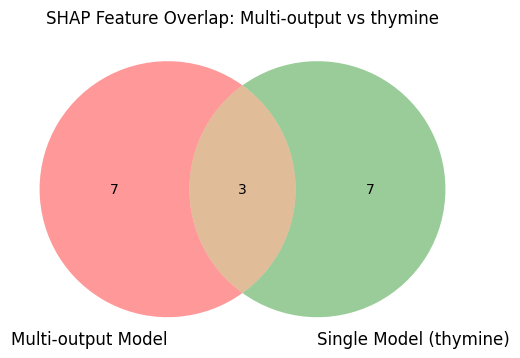

Overlapping features: RBP4, ABCG8, GC

--- SHAP Feature Overlap: Multi-output vs uracil ---


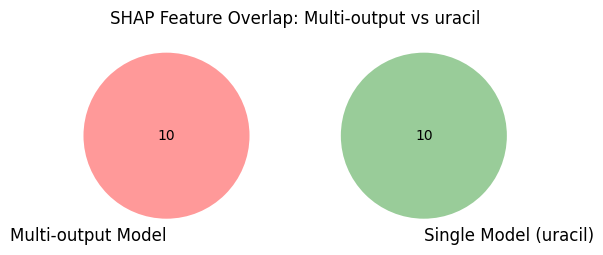

No overlapping features.

--- SHAP Feature Overlap: Multi-output vs cytidine ---


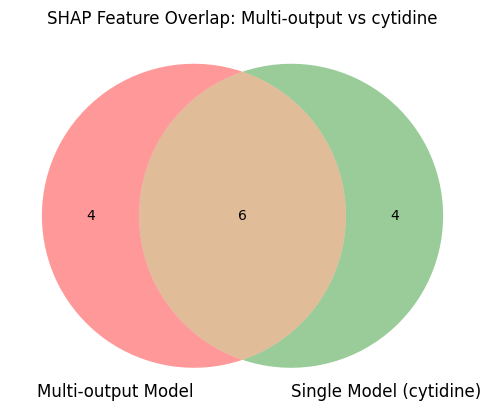

Overlapping features: RBP4, FOSL1, TPH1, GC, THEM5, HS3ST6

--- SHAP Feature Overlap: Multi-output vs hypoxanthine ---


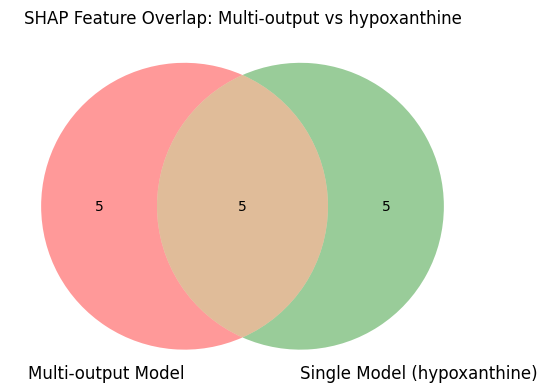

Overlapping features: FOSL1, TPH1, SLC1A3, THEM5, HS3ST6


In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


multi_shap_top10 = set(multi_shap_importance.index)

for metabolite in y_train.columns:
    print(f"\n--- SHAP Feature Overlap: Multi-output vs {metabolite} ---")


    single_shap_top10 = set(df_mean_abs_shap[metabolite].sort_values(ascending=False).head(10).index)


    plt.figure(figsize=(6, 6))
    venn2([multi_shap_top10, single_shap_top10], ('Multi-output Model', f'Single Model ({metabolite})'))
    plt.title(f'SHAP Feature Overlap: Multi-output vs {metabolite}')
    plt.savefig(f'{results_path}/SHAP Feature Overlap ({metabolite}).svg', bbox_inches = 'tight')
    plt.show()

    overlap = multi_shap_top10.intersection(single_shap_top10)
    if overlap:
        print(f"Overlapping features: {', '.join(overlap)}")
    else:
        print("No overlapping features.")